# Charger le datraframe #

In [1444]:
import pandas as pd
import unicodedata
df = pd.read_csv(
    "ncr_ride_bookings.csv",
    sep=",",
    quotechar='"',
    encoding="utf-8"
)

df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method',
       'Valeurs_conformes'],
      dtype='str')

In [1445]:
print(df["Booking Status"].value_counts(dropna=False))

Booking Status
Success                  93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [1446]:
print(df["Booking Status"].unique())

<StringArray>
[      'No Driver Found',            'Incomplete',               'Success',
   'Cancelled by Driver', 'Cancelled by Customer']
Length: 5, dtype: str


In [1447]:
print(df["Booking Status"].value_counts(dropna=False))

Booking Status
Success                  93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


# Supprime les espaces au début et à la fin des noms de colonnes #

In [1448]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method',
       'Valeurs_conformes'],
      dtype='str')


# Supprimer les doublons #

In [1449]:
df = df.drop_duplicates()
df[df.duplicated(keep=False)]


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Valeurs_conformes


# Supprimer les espaces en début de chaque valeur #

In [1450]:
# Sélection des colonnes de type chaîne
string_cols = df.select_dtypes(include="object").columns

# Suppression des espaces en début et fin de chaque valeur
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip())
# remplacer les espaces multiples par un seul
df[string_cols] = df[string_cols].apply(
    lambda col: col.str.replace(r"\s+", " ", regex=True).str.strip()
)
# vérifier que les espaces ont bien été supprimés
print(df.columns.tolist())

for col in string_cols:
    print(df[col].head())



C:\Users\yannb\AppData\Local\Temp\ipykernel_10824\4183909105.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include="object").columns


['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method', 'Valeurs_conformes']
0    2024/03/23
1    2024/11/29
2    2024/08/23
3    2024/10/21
4    2024/09/16
Name: Date, dtype: str
0    12:29:38
1    18:01:39
2    08:56:10
3    17:17:25
4    22:08:00
Name: Time, dtype: str
0    CNR5884300
1    CNR1326809
2    CNR8494506
3    CNR8906825
4    CNR1950162
Name: Booking ID, dtype: str
0    No Driver Found
1         Incomplete
2            Success
3            Success
4            Success
Name: Booking Status, dtype: str
0    CID1982111
1    CID4604802
2    CID9202816
3    CID2610914
4    CID9933542
Name: Customer ID, dtype: str
0           E-Bike
1   

# Uniformiser les booking id #

In [1451]:
id_cols = ["Booking ID", "Customer ID"]

for col in id_cols:
    df[col] = df[col].str.replace('"', '', regex=False).str.strip()
    

# Uniformiser les dates #

In [1452]:
import re
from datetime import datetime

def uniformiser_date(date):

    if not isinstance(date, str):
        return None

    date = date.strip()

    # Uniformiser les séparateurs
    date = re.sub(r"\s*-\s*", "-", date)
    date = re.sub(r"\s+", "-", date)
    date = date.replace("/", "-")

    formats = [
        "%Y-%m-%d",   # 1995-02-10
        "%m-%d-%Y",   # 09-21-1972
        "%d-%m-%Y",   # 23-07-2008
        "%d-%b-%y",   # 22-Feb-04
        "%d-%B-%Y",   # 22-February-2004
        "%d-%b-%Y",   # 22-Feb-2004
    ]

    for fmt in formats:
        try:
            d = datetime.strptime(date, fmt)
            return d.strftime("%Y/%m/%d")
        except ValueError:
            pass

    return None

df["Date"] = df["Date"].apply(uniformiser_date)



# Nettoyage des colonnes numériques #

In [1453]:
cols = [
    "Cancelled Rides by Customer",
    "Cancelled Rides by Driver",
    "Incomplete Rides"
]

# Vérification avant nettoyage
print("Avant nettoyage :")
print(df[cols].isna().sum())

# Remplacement des NaN par 0
df[cols] = df[cols].fillna(0)

# Vérification après nettoyage
print("\nAprès nettoyage :")
print(df[cols].isna().sum())

# Taux d'annulation
customer_cancel_rate = df["Cancelled Rides by Customer"].mean() * 100
driver_cancel_rate = df["Cancelled Rides by Driver"].mean() * 100

# Vérification des valeurs
print("\nRépartition des annulations client :")
print(df["Cancelled Rides by Customer"].value_counts(dropna=False))

print("\nRépartition des annulations chauffeur :")
print(df["Cancelled Rides by Driver"].value_counts(dropna=False))

# Affichage des taux
print(f"Taux d'annulation par le client : {customer_cancel_rate:.2f}%")
print(f"Taux d'annulation par le chauffeur : {driver_cancel_rate:.2f}%")
['Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason']




Avant nettoyage :
Cancelled Rides by Customer    0
Cancelled Rides by Driver      0
Incomplete Rides               0
dtype: int64

Après nettoyage :
Cancelled Rides by Customer    0
Cancelled Rides by Driver      0
Incomplete Rides               0
dtype: int64

Répartition des annulations client :
Cancelled Rides by Customer
0.0    139500
1.0     10500
Name: count, dtype: int64

Répartition des annulations chauffeur :
Cancelled Rides by Driver
0.0    123000
1.0     27000
Name: count, dtype: int64
Taux d'annulation par le client : 7.00%
Taux d'annulation par le chauffeur : 18.00%


['Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason']

In [1454]:
df.isna().sum()



Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer              0
Reason for cancelling by Customer        0
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                         0
Incomplete Rides Reason                  0
Booking Value                        48000
Ride Distance                        48000
Driver Ratings                       57000
Customer Rating                      57000
Payment Method                           0
Valeurs_conformes                        0
dtype: int64

In [1455]:
colonnes_nan = [
    "Booking Value",
    "Ride Distance",
    "Payment Method",
    "Driver Ratings",
    "Customer Rating"
]

for colonne in colonnes_nan:
    print("\n---", colonne, "---")
    print(
        df[df[colonne].isna()]["Booking Status"]
        .value_counts()
    )



--- Booking Value ---


Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Name: count, dtype: int64

--- Ride Distance ---
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Name: count, dtype: int64

--- Payment Method ---
Series([], Name: count, dtype: int64)

--- Driver Ratings ---
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

--- Customer Rating ---
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


# Nettoyer les catégories #

In [1456]:
for colonne in [
    "Vehicle Type",
    "Booking Status",
    "Payment Method",
    "Pickup Location",
    "Drop Location"
]:
    print(f"\n--- {colonne} ---")
    print(sorted(df[colonne].dropna().unique()))



--- Vehicle Type ---
['Auto', 'Bike', 'E-Bike', 'Go Mini', 'Go Sedan', 'Premium Sedan', 'Uber XL']

--- Booking Status ---


['Cancelled by Customer', 'Cancelled by Driver', 'Incomplete', 'No Driver Found', 'Success']

--- Payment Method ---
['Card', 'Cash', 'No Payment', 'UPI', 'Uber Wallet']

--- Pickup Location ---
['AIIMS', 'Adarsh Nagar', 'Akshardham', 'Ambience Mall', 'Anand Vihar', 'Anand Vihar ISBT', 'Ardee City', 'Arjangarh', 'Ashok Park Main', 'Ashok Vihar', 'Ashram', 'Aya Nagar', 'Azadpur', 'Badarpur', 'Badshahpur', 'Bahadurgarh', 'Barakhamba Road', 'Basai Dhankot', 'Bhikaji Cama Place', 'Bhiwadi', 'Botanical Garden', 'Central Secretariat', 'Chanakyapuri', 'Chandni Chowk', 'Chhatarpur', 'Chirag Delhi', 'Civil Lines Gurgaon', 'Connaught Place', 'Cyber Hub', 'DLF City Court', 'DLF Phase 3', 'Delhi Gate', 'Dilshad Garden', 'Dwarka Mor', 'Dwarka Sector 21', 'Faridabad Sector 15', 'GTB Nagar', 'Ghaziabad', 'Ghitorni', 'Ghitorni Village', 'Golf Course Road', 'Govindpuri', 'Greater Kailash', 'Greater Noida', 'Green Park', 'Gurgaon Railway Station', 'Gurgaon Sector 29', 'Gurgaon Sector 56', 'Gwal Pahari',

# Vehicle Type #

In [1457]:
vehicle_type_remplacement = {
    "Auto": "Auto",
    "Bike": "Bike",
    "eBike": "E-Bike",
    "Mini": "Go Mini",
    "Sedan": "Go Sedan",
    "Premier Sedan": "Premium Sedan",
    "XL": "Uber XL",
   
}

df["Vehicle Type"] = df["Vehicle Type"].replace(vehicle_type_remplacement)


# Booking Status #

In [1458]:
# Remplacer Completed
df["Booking Status"] = df["Booking Status"].replace({
    "Completed": "Success"
})

# Remplacer directement selon les indicateurs
df.loc[df["Cancelled Rides by Driver"] == 1, "Booking Status"] = "Cancelled by Driver"

df.loc[df["Cancelled Rides by Customer"] == 1, "Booking Status"] = "Cancelled by Customer"

print(df["Booking Status"].value_counts())



Booking Status
Success                  93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


# Payment method #

In [1459]:

payment_method_remplacement = {
    "Cash": "Cash",
    "Credit Card": "Card",
    "Debit Card": "Card",
    "UPI": "UPI",
     "Wallet": "Uber Wallet",
   
}

# Uniformisation des catégories

df["Payment Method"] = df["Payment Method"].replace(
    payment_method_remplacement
)

# Remplacement des valeurs manquantes
df["Payment Method"] = df["Payment Method"].fillna(
    "No Payment"
)
print(df["Payment Method"].value_counts(dropna=False))


Payment Method
No Payment     48000
UPI            45909
Cash           25367
Card           18448
Uber Wallet    12276
Name: count, dtype: int64


# Pickup Location et Drop Location #

In [1460]:
df["Pickup Location"] = (
    df["Pickup Location"]
    .str.strip()
)
df["Drop Location"] = (
    df["Drop Location"]
    .str.strip()
)


In [1461]:
df[df["Ride Distance"] < 0]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Valeurs_conformes


# Vérifier les valeurs aberrantes #

# Ride Distance #

In [1462]:
(df["Ride Distance"] < 0).sum()

np.int64(0)

# Booking Value #

In [1463]:
df[df["Booking Value"] < 0]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Valeurs_conformes


# Driver Ratings # 

In [1464]:
df[
    (df["Driver Ratings"] < 0)
    |
    (df["Driver Ratings"] > 5)
]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Valeurs_conformes


# Customer Ratings #

In [1465]:
df[
    (df["Customer Rating"] < 0)
    |
    (df["Customer Rating"] > 5)
]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Valeurs_conformes


In [1466]:
print(
    "Driver Ratings incorrectes :",
    ((df["Driver Ratings"] < 0) | (df["Driver Ratings"] > 5)).sum()
)

print(
    "Customer Rating incorrectes :",
    ((df["Customer Rating"] < 0) | (df["Customer Rating"] > 5)).sum()
)

Driver Ratings incorrectes : 0
Customer Rating incorrectes : 0


In [1467]:
df["Valeurs_conformes"] = "✅"

df.loc[
    (df["Ride Distance"] < 0)
    |
    (df["Booking Value"] < 0)
    |
    (df["Driver Ratings"] > 5)
    |
    (df["Customer Rating"] > 5),
    "Valeurs_conformes"
] = "❌"

In [1468]:
df[df["Valeurs_conformes"] == "❌"]
df[df["Valeurs_conformes"] == "✅"]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Valeurs_conformes
0,2024/03/23,12:29:38,CNR5884300,No Driver Found,CID1982111,E-Bike,Palam Vihar,Jhilmil,NaN,NaN,...,0.0,Not Applicable,0.0,Not Applicable,NaN,NaN,NaN,NaN,No Payment,✅
1,2024/11/29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,0.0,Not Applicable,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,✅
2,2024/08/23,08:56:10,CNR8494506,Success,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,0.0,Not Applicable,0.0,Not Applicable,627.0,13.58,4.9,4.9,Card,✅
3,2024/10/21,17:17:25,CNR8906825,Success,CID2610914,Premium Sedan,Central Secretariat,Inderlok,13.1,28.5,...,0.0,Not Applicable,0.0,Not Applicable,416.0,34.02,4.6,5.0,UPI,✅
4,2024/09/16,22:08:00,CNR1950162,Success,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,0.0,Not Applicable,0.0,Not Applicable,737.0,48.21,4.1,4.3,UPI,✅
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024/11/11,19:34:01,CNR6500631,Success,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,...,0.0,Not Applicable,0.0,Not Applicable,475.0,40.08,3.7,4.1,Uber Wallet,✅
149996,2024/11/24,15:55:09,CNR2468611,Success,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,0.0,Not Applicable,0.0,Not Applicable,1093.0,21.31,4.8,5.0,UPI,✅
149997,2024/09/18,10:55:15,CNR6358306,Success,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,0.0,Not Applicable,0.0,Not Applicable,852.0,15.93,3.9,4.4,Cash,✅
149998,2024/10/05,07:53:34,CNR3030099,Success,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,0.0,Not Applicable,0.0,Not Applicable,333.0,45.54,4.1,3.7,UPI,✅


# Nettoyer les statuts des réservations #

In [1469]:
print(df["Booking Status"].value_counts(dropna=False))
print(df["Booking Status"].value_counts())

Booking Status
Success                  93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64
Booking Status
Success                  93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [1470]:

# df["Booking Status"] = (
#     df["Booking Status"]
#     .replace(booking_status_remplacement)
# # )
print(df["Booking Status"].value_counts())

Booking Status
Success                  93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [1471]:
print(df["Booking Status"].unique())

<StringArray>
[      'No Driver Found',            'Incomplete',               'Success',
   'Cancelled by Driver', 'Cancelled by Customer']
Length: 5, dtype: str


In [1472]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method',
       'Valeurs_conformes'],
      dtype='str')

In [1473]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,150000.000000,150000.000000,150000.000000,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,0.070000,0.180000,0.060000,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.255148,0.384189,0.237488,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,0.000000,0.000000,0.000000,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,0.000000,0.000000,0.000000,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,0.000000,0.000000,0.000000,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,0.000000,0.000000,0.000000,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.000000,1.000000,1.000000,4277.000000,50.000000,5.000000,5.000000


In [1474]:
print(df.dtypes)

Date                                     str
Time                                     str
Booking ID                               str
Booking Status                           str
Customer ID                              str
Vehicle Type                             str
Pickup Location                          str
Drop Location                            str
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer        str
Cancelled Rides by Driver            float64
Driver Cancellation Reason               str
Incomplete Rides                     float64
Incomplete Rides Reason                  str
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                           str
Valeurs_conformes                        str
dtype: obj

In [1475]:
di = df.isna().sum()
ds = df.info()
print(di, ds)


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        150000 non-null  float64
 11  Reason for cancelling by Customer  150000 non-null

In [1476]:
df.to_csv("ncr_ride_bookings.csv", index=False, encoding="utf-8")

# Distribution de la valeur des réservations #

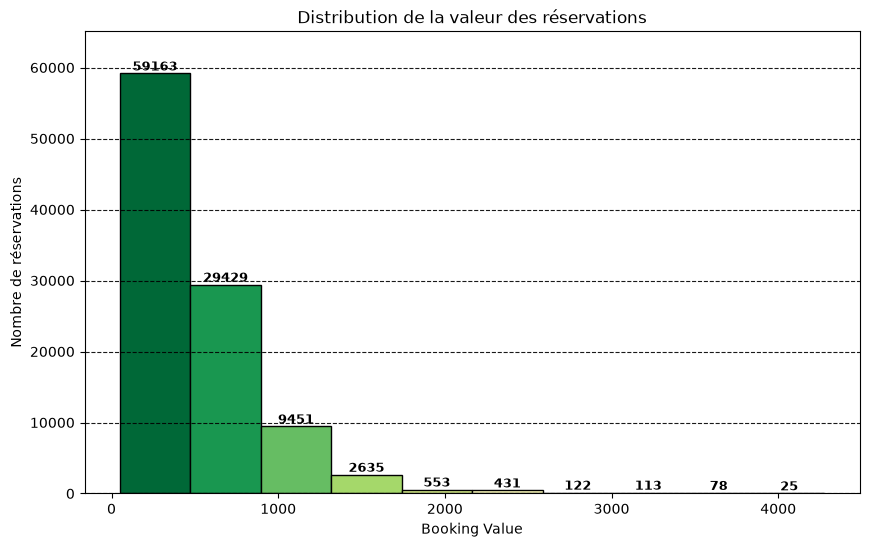

In [1477]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(10,6))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Booking Value"].dropna(),
    bins=10,
    edgecolor="black"
)

# Normalisation des valeurs des classes
norm = mcolors.Normalize(vmin=bins.min(), vmax=bins.max())
cmap = plt.colormaps["RdYlGn_r"]  # Vert → Jaune → Rouge

# Attribution des couleurs
for i, patch in enumerate(patches):
    patch.set_facecolor(cmap(norm(bins[i])))

# Affichage des effectifs sur chaque barre
for count, patch in zip(n, patches):
    if count > 0:  # N'affiche pas les classes vides
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.title("Distribution de la valeur des réservations")
plt.xlabel("Booking Value")
plt.ylabel("Nombre de réservations")
plt.grid(axis="y", linestyle="--", alpha=0.9, color="black")

# Laisse un peu d'espace au-dessus des barres pour les étiquettes
plt.ylim(0, max(n) * 1.1)

plt.show()

# Distribution de la distance en fonction du nombre de courses #

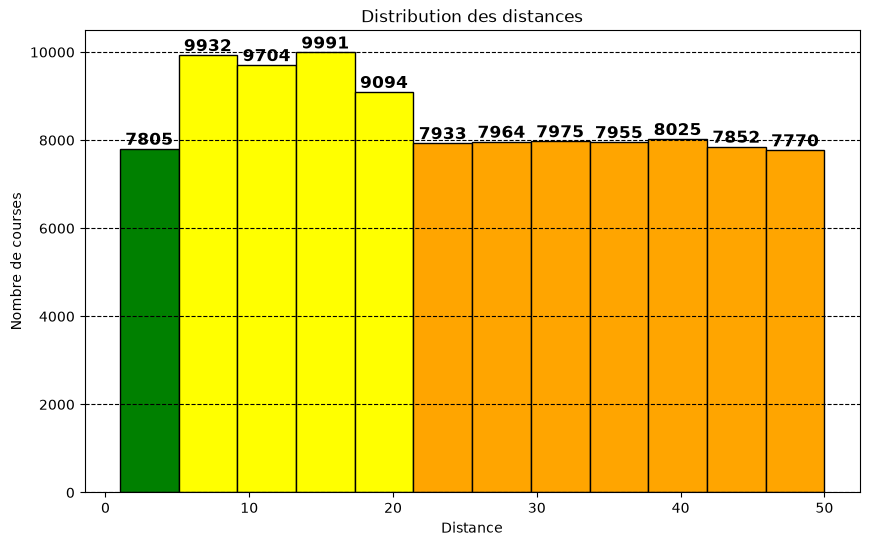

In [1478]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Ride Distance"].dropna(),
    bins=12,
    edgecolor="black"

)

# Coloration selon la distance
for i, patch in enumerate(patches):
    if bins[i] < 5:
        patch.set_facecolor("green")
    elif bins[i] < 20:
        patch.set_facecolor("yellow")
    elif bins[i] < 50:
        patch.set_facecolor("orange")
    else:
        patch.set_facecolor("red")

# Affichage des effectifs sur chaque barre
for count, patch in zip(n, patches):
    if count > 0:  # n'affiche pas les classes vides
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight= "bold"
            
        )

        

plt.title("Distribution des distances")
plt.xlabel("Distance")
plt.ylabel("Nombre de courses")
plt.grid(axis="y", linestyle="--", alpha=1.0, color="black")

plt.show()

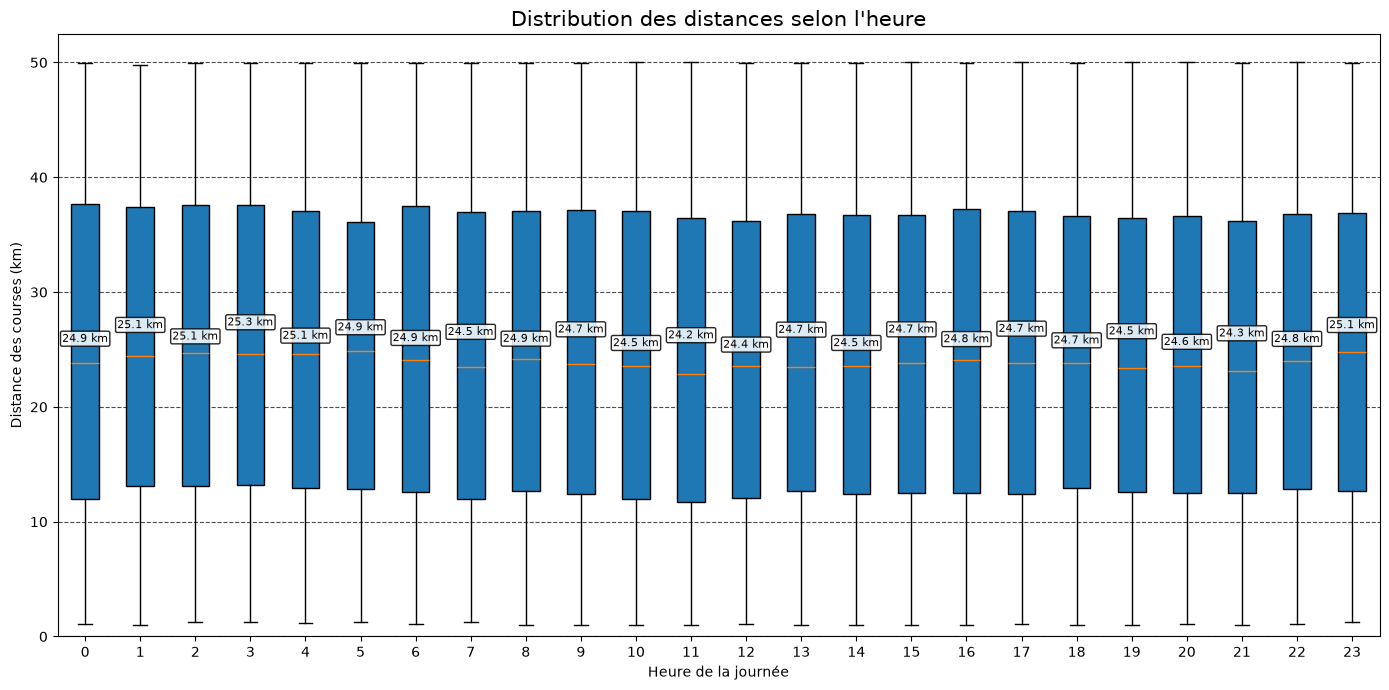

In [1479]:
import matplotlib.pyplot as plt
import pandas as pd


# Conversion de l'heure
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S",
    errors="coerce"
)

# Extraction de l'heure
df["Heure"] = df["Time"].dt.hour


# Données par heure
donnees = [
    df.loc[df["Heure"] == h, "Ride Distance"].dropna()
    for h in range(24)
]


# Distance moyenne par heure
moyennes_heure = (
    df.groupby("Heure")["Ride Distance"]
    .mean()
)


# Création du graphique
fig, ax = plt.subplots(figsize=(14,7))


ax.boxplot(
    donnees,
    tick_labels=range(24),
    patch_artist=True
)


# Affichage des moyennes avec décalage pour éviter les chevauchements
for i, valeur in enumerate(moyennes_heure):

    decalage = 0.8 if i % 2 == 0 else 1.8

    ax.text(
        i + 1,
        valeur + decalage,
        f"{valeur:.1f} km",
        ha="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

ax.set_ylim(
    0,
    max(moyennes_heure.max() + 5, ax.get_ylim()[1])
)
ax.set_title(
    "Distribution des distances selon l'heure",
    fontsize=15
)

ax.set_xlabel(
    "Heure de la journée"
)

ax.set_ylabel(
    "Distance des courses (km)"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.tight_layout()
plt.show()

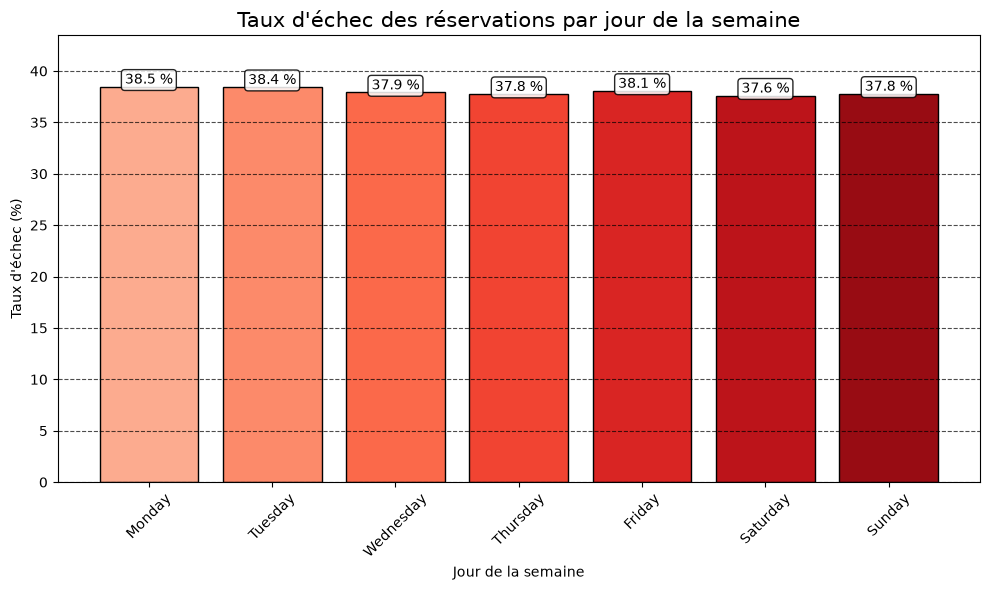

In [1480]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Conversion de la date
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)


# Extraction du jour de la semaine
df["Jour"] = df["Date"].dt.day_name()


# Ordre des jours
ordre_jours = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


# Statuts considérés comme des échecs
statuts_echec = [
    "Cancelled by Customer",
    "Cancelled by Driver",
    "Incomplete",
    "No Driver Found"
]


# Nombre total de réservations par jour
reservations_jour = (
    df.groupby("Jour")
    .size()
)


# Nombre d'échecs par jour
echecs_jour = (
    df[df["Booking Status"].isin(statuts_echec)]
    .groupby("Jour")
    .size()
)


# Calcul du taux d'échec
taux_echec_jour = (
    echecs_jour
    .div(reservations_jour)
    .mul(100)
    .reindex(ordre_jours)
    .fillna(0)
)


# Couleurs
couleurs = plt.cm.Reds(
    np.linspace(0.3, 0.9, len(taux_echec_jour))
)


# Graphique
fig, ax = plt.subplots(figsize=(10,6))


bars = ax.bar(
    taux_echec_jour.index,
    taux_echec_jour.values,
    color=couleurs,
    edgecolor="black"
)


# Valeurs avec bbox
for bar in bars:
    hauteur = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        hauteur + 0.3,
        f"{hauteur:.1f} %",
        ha="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


# Marge en haut
ax.set_ylim(
    0,
    taux_echec_jour.max() + 5
)


ax.set_title(
    "Taux d'échec des réservations par jour de la semaine",
    fontsize=15
)

ax.set_xlabel(
    "Jour de la semaine"
)

ax.set_ylabel(
    "Taux d'échec (%)"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

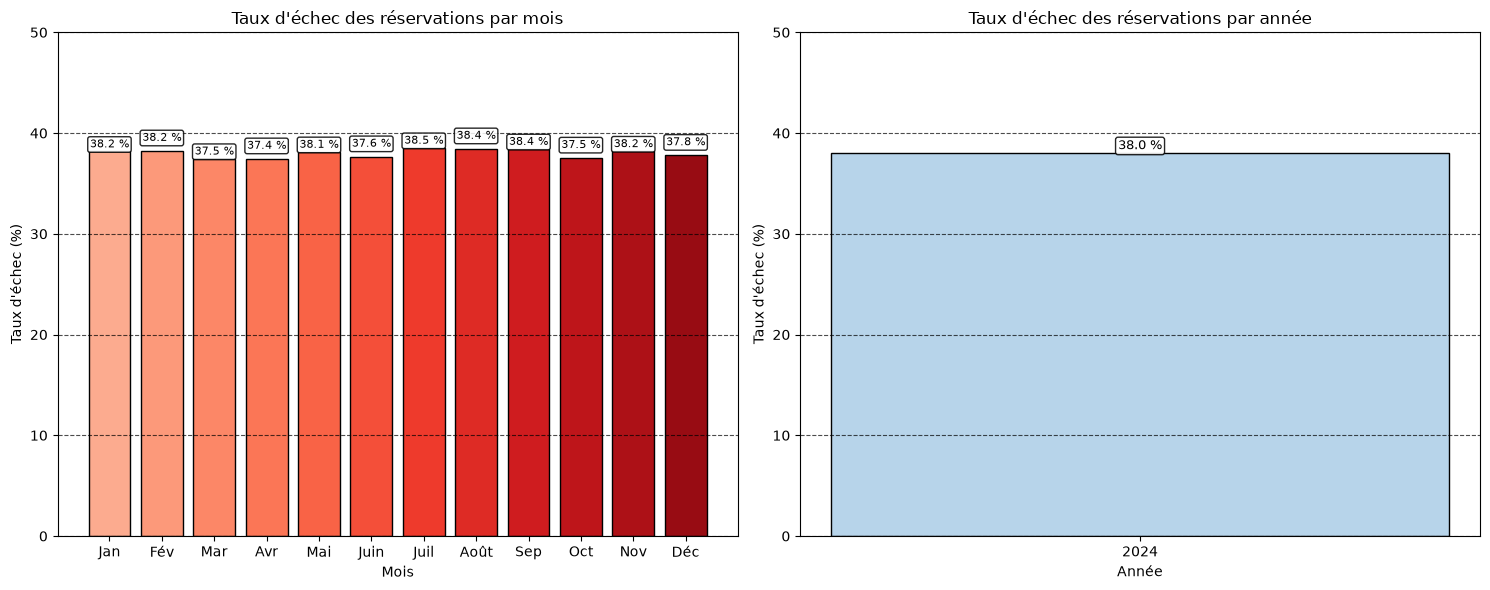

In [1481]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Conversion de la date
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)


# Extraction mois et année
df["Mois"] = df["Date"].dt.month
df["Annee"] = df["Date"].dt.year


# Statuts considérés comme des échecs
statuts_echec = [
    "Cancelled by Customer",
    "Cancelled by Driver",
    "Incomplete",
    "No Driver Found"
]


# ==========================
# Taux d'échec par mois
# ==========================

reservations_mois = (
    df.groupby("Mois")
    .size()
)


echecs_mois = (
    df[df["Booking Status"].isin(statuts_echec)]
    .groupby("Mois")
    .size()
)


taux_echec_mois = (
    echecs_mois
    .div(reservations_mois)
    .mul(100)
    .fillna(0)
)


noms_mois = [
    "Jan",
    "Fév",
    "Mar",
    "Avr",
    "Mai",
    "Juin",
    "Juil",
    "Août",
    "Sep",
    "Oct",
    "Nov",
    "Déc"
]


taux_echec_mois.index = noms_mois


# ==========================
# Taux d'échec par année
# ==========================

reservations_annee = (
    df.groupby("Annee")
    .size()
)


echecs_annee = (
    df[df["Booking Status"].isin(statuts_echec)]
    .groupby("Annee")
    .size()
)


taux_echec_annee = (
    echecs_annee
    .div(reservations_annee)
    .mul(100)
    .fillna(0)
)



# ==========================
# Création des graphiques
# ==========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15,6)
)


# Couleurs
couleurs_mois = plt.cm.Reds(
    np.linspace(0.3,0.9,len(taux_echec_mois))
)

couleurs_annee = plt.cm.Blues(
    np.linspace(0.3,0.9,len(taux_echec_annee))
)


# --------------------------
# Graphique mois
# --------------------------

bars1 = axes[0].bar(
    taux_echec_mois.index,
    taux_echec_mois.values,
    color=couleurs_mois,
    edgecolor="black"
)


for i, bar in enumerate(bars1):

    hauteur = bar.get_height()

    decalage = 0.4 if i % 2 == 0 else 1

    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        hauteur + decalage,
        f"{hauteur:.1f} %",
        ha="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


axes[0].set_title(
    "Taux d'échec des réservations par mois"
)

axes[0].set_xlabel(
    "Mois"
)

axes[0].set_ylabel(
    "Taux d'échec (%)"
)



# --------------------------
# Graphique année
# --------------------------

bars2 = axes[1].bar(
    taux_echec_annee.index.astype(str),
    taux_echec_annee.values,
    color=couleurs_annee,
    edgecolor="black"
)


for i, bar in enumerate(bars2):

    hauteur = bar.get_height()

    axes[1].text(
        bar.get_x()+bar.get_width()/2,
        hauteur + 0.4,
        f"{hauteur:.1f} %",
        ha="center",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


axes[1].set_title(
    "Taux d'échec des réservations par année"
)

axes[1].set_xlabel(
    "Année"
)

axes[1].set_ylabel(
    "Taux d'échec (%)"
)


# Mise en forme
for ax in axes:

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.7,
        color="black"
    )

    ax.set_ylim(
        0,
        max(ax.get_ylim()[1], 50)
    )


plt.tight_layout()
plt.show()

# Répartitions des réservations #

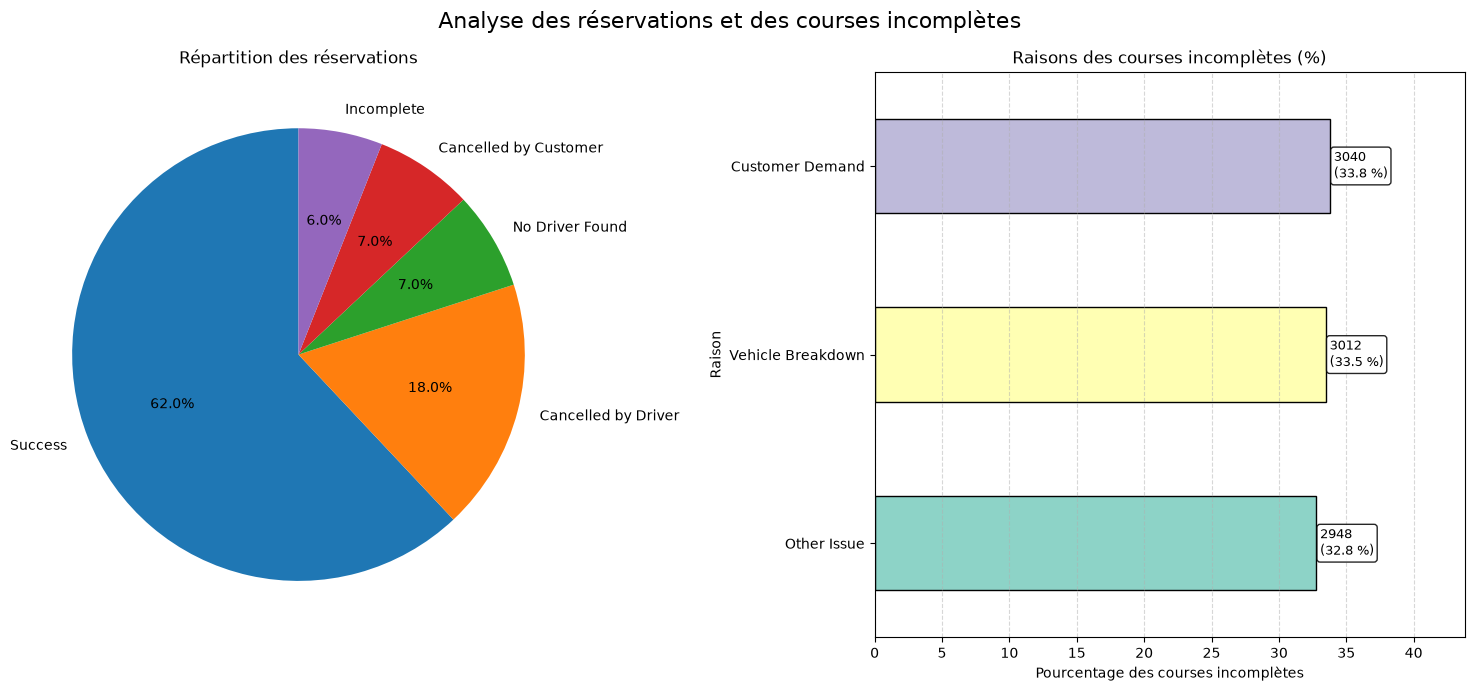

In [1482]:
import matplotlib.pyplot as plt


# ==========================
# Répartition des statuts
# ==========================

status = df["Booking Status"].value_counts()


# ==========================
# Raisons des courses incomplètes
# ==========================

incomplete_reason = (
    df[df["Incomplete Rides"] == 1]
    ["Incomplete Rides Reason"]
    .dropna()
    .value_counts()
    .sort_values()
)


# Pourcentage des incomplete
incomplete_pct = (
    incomplete_reason
    .div(incomplete_reason.sum())
    .mul(100)
)


# ==========================
# Création des graphiques
# ==========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15,7)
)


# --------------------------
# Camembert des statuts
# --------------------------

axes[0].pie(
    status.values,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[0].set_title(
    "Répartition des réservations"
)


# --------------------------
# Barres des incomplete
# --------------------------

couleurs = plt.cm.Set3(range(len(incomplete_pct)))


incomplete_pct.plot(
    kind="barh",
    ax=axes[1],
    color=couleurs,
    edgecolor="black"
)


axes[1].set_title(
    "Raisons des courses incomplètes (%)"
)

axes[1].set_xlabel(
    "Pourcentage des courses incomplètes"
)

axes[1].set_ylabel(
    "Raison"
)


# Marge pour les valeurs
axes[1].set_xlim(
    0,
    incomplete_pct.max() + 10
)


# Affichage nombre + %
for i, (pct, nombre) in enumerate(
    zip(incomplete_pct, incomplete_reason)
):
    axes[1].text(
        pct + 0.3,
        i,
        f"{nombre}\n({pct:.1f} %)",
        va="center",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)


plt.suptitle(
    "Analyse des réservations et des courses incomplètes",
    fontsize=16
)

plt.tight_layout()
plt.show()

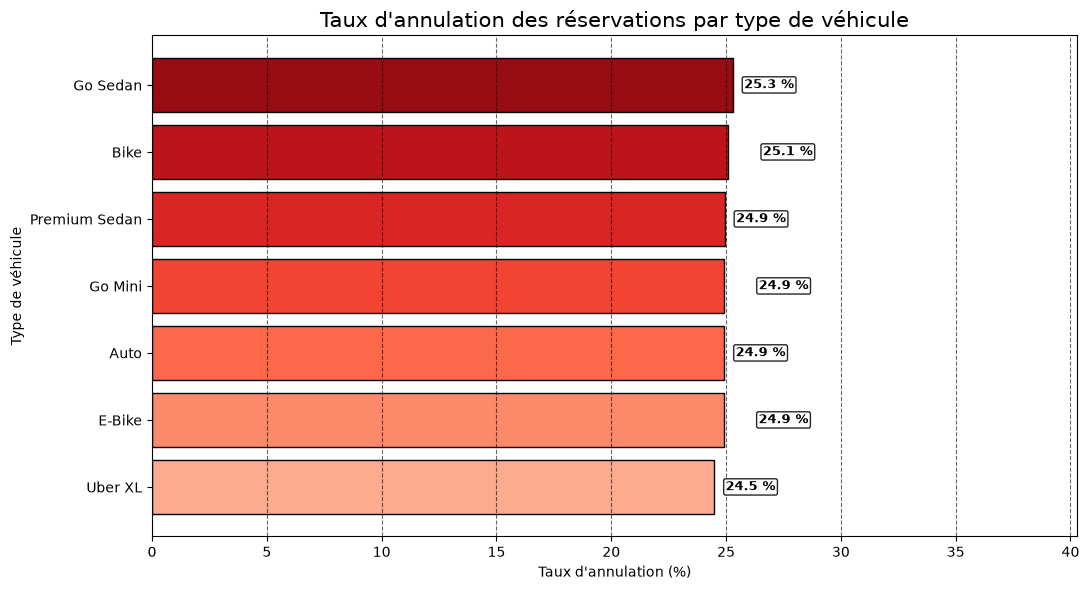

In [1483]:
import matplotlib.pyplot as plt
import numpy as np


# Types de véhicules
reservations_vehicule = (
    df.groupby("Vehicle Type")
    .size()
)


# Annulations
statuts_annulation = [
    "Cancelled by Customer",
    "Cancelled by Driver"
]


annulations_vehicule = (
    df[df["Booking Status"].isin(statuts_annulation)]
    .groupby("Vehicle Type")
    .size()
)


# Taux d'annulation
taux_annulation = (
    annulations_vehicule
    .div(reservations_vehicule)
    .mul(100)
    .fillna(0)
    .sort_values()
)


# Couleurs
couleurs = plt.cm.Reds(
    np.linspace(0.3, 0.9, len(taux_annulation))
)


# Graphique
fig, ax = plt.subplots(figsize=(11,6))


bars = ax.barh(
    taux_annulation.index,
    taux_annulation.values,
    color=couleurs,
    edgecolor="black"
)


# Marge suffisante à droite
ax.set_xlim(
    0,
    taux_annulation.max() + 15
)


# Valeurs avec bbox espacées
for i, bar in enumerate(bars):

    largeur = bar.get_width()

    # alternance pour éviter les contacts
    decalage = 0.5 if i % 2 == 0 else 1.5

    ax.text(
        largeur + decalage,
        bar.get_y() + bar.get_height()/2,
        f"{largeur:.1f} %",
        va="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


ax.set_title(
    "Taux d'annulation des réservations par type de véhicule",
    fontsize=15
)


ax.set_xlabel(
    "Taux d'annulation (%)"
)

ax.set_ylabel(
    "Type de véhicule"
)


# Pointillés verticaux
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.6,
    color="black"
)


plt.tight_layout()
plt.show()

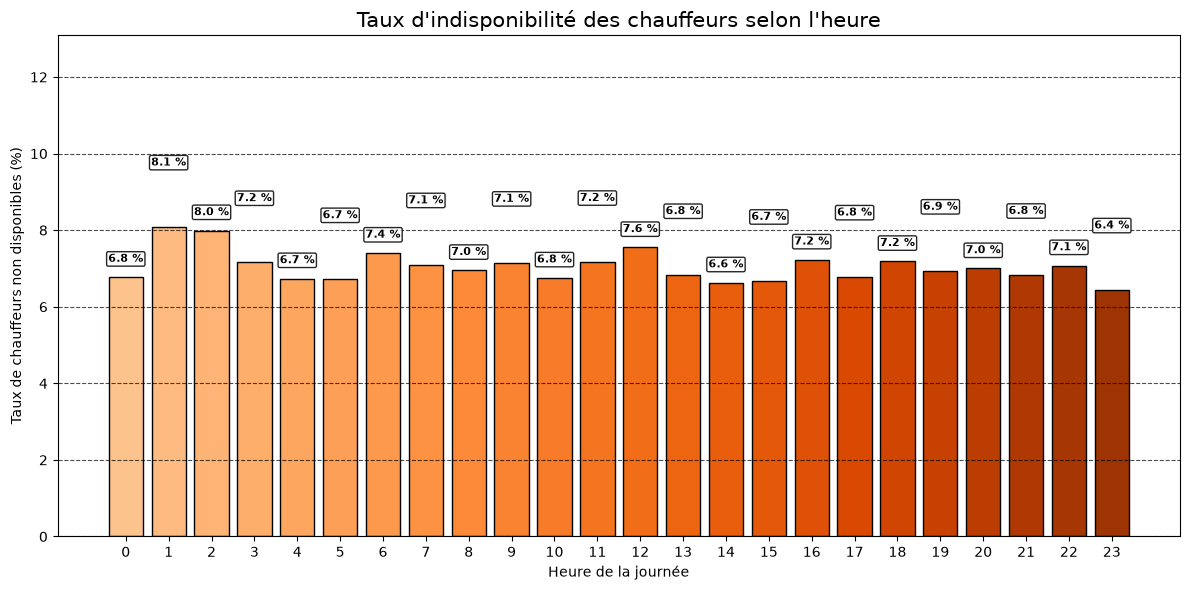

In [1484]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Conversion de l'heure
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S",
    errors="coerce"
)

# Extraction de l'heure
df["Heure"] = df["Time"].dt.hour


# Nombre total de réservations par heure
reservations_heure = (
    df.groupby("Heure")
    .size()
)


# Nombre de chauffeurs non trouvés par heure
indisponibilite = (
    df[df["Booking Status"] == "No Driver Found"]
    .groupby("Heure")
    .size()
)


# Taux d'indisponibilité
taux_indisponibilite = (
    indisponibilite
    .div(reservations_heure)
    .mul(100)
    .fillna(0)
    .reindex(range(24), fill_value=0)
)


# Couleurs
couleurs = plt.cm.Oranges(
    np.linspace(0.3,0.9,len(taux_indisponibilite))
)


# Graphique
fig, ax = plt.subplots(figsize=(12,6))


bars = ax.bar(
    taux_indisponibilite.index,
    taux_indisponibilite.values,
    color=couleurs,
    edgecolor="black"
)


# Valeurs avec bbox décalées pour éviter les chevauchements
for i, bar in enumerate(bars):

    hauteur = bar.get_height()

    # Décalage vertical alterné
    decalage = 0.4 if i % 2 == 0 else 1.6

    ax.text(
        bar.get_x() + bar.get_width()/2,
        hauteur + decalage,
        f"{hauteur:.1f} %",
        ha="center",
        fontsize=8,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

# Marge verticale
ax.set_ylim(
    0,
    taux_indisponibilite.max() + 5
)


ax.set_title(
    "Taux d'indisponibilité des chauffeurs selon l'heure",
    fontsize=15
)

ax.set_xlabel(
    "Heure de la journée"
)

ax.set_ylabel(
    "Taux de chauffeurs non disponibles (%)"
)


ax.set_xticks(range(24))


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.tight_layout()
plt.show()

# Top 15 des lieux où il y a eu le plus de commandes #

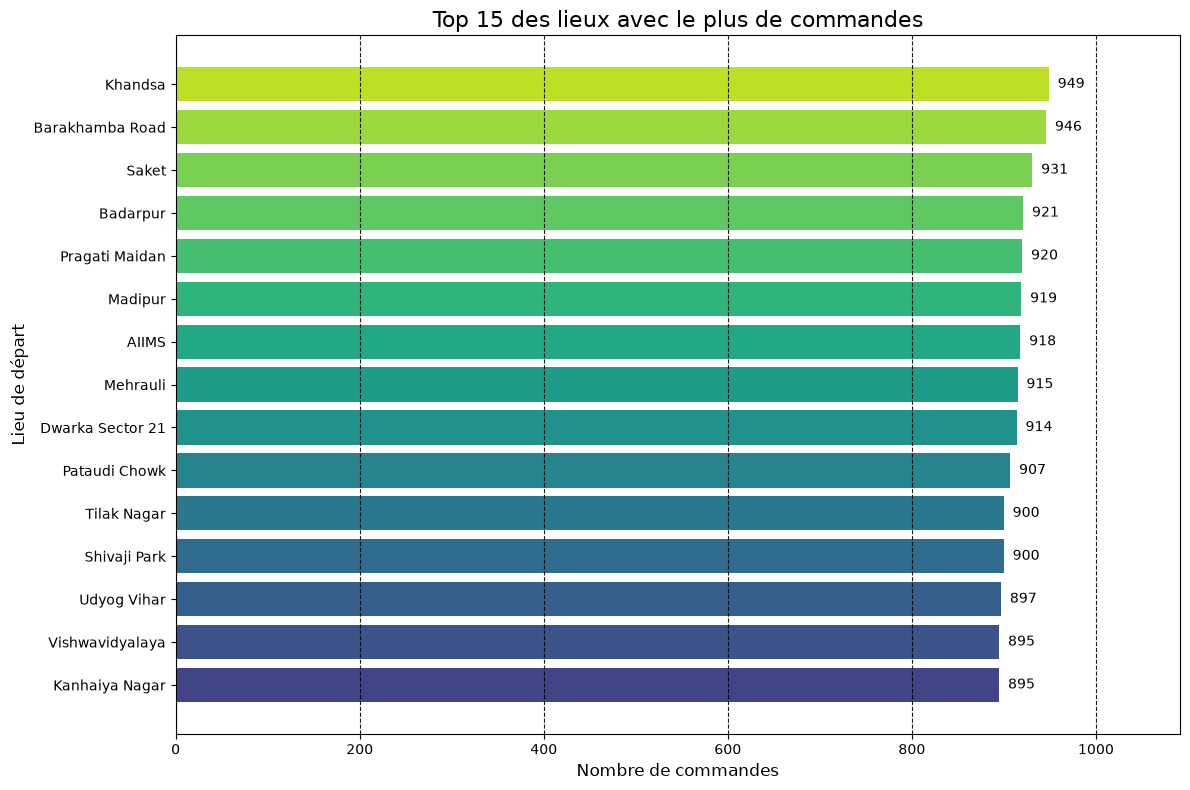

In [1485]:
import matplotlib.pyplot as plt
import numpy as np

# Compter les commandes par lieu de départ
commandes_lieux = (
    df["Pickup Location"]
    .value_counts()
    .head(15)
    .sort_values()
)

# Création du graphique
plt.figure(figsize=(12, 8))

# Création des couleurs
couleurs = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(commandes_lieux))
)

plt.barh(
    commandes_lieux.index,
    commandes_lieux.values,
    color=couleurs
)

# Ajouter les valeurs sur les barres
for i, valeur in enumerate(commandes_lieux.values):
    plt.text(
        valeur + max(commandes_lieux.values)*0.01,
        i,
        f"{valeur}",
        va="center",
        fontsize=10
    )

# Ajouter une marge à droite
plt.xlim(
    0,
    max(commandes_lieux.values) * 1.15
)

plt.title(
    "Top 15 des lieux avec le plus de commandes",
    fontsize=16
)

plt.xlabel(
    "Nombre de commandes",
    fontsize=12
)

plt.ylabel(
    "Lieu de départ",
    fontsize=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.9,
    color="black"
)

plt.tight_layout()
plt.show()

# Nombre de commandes selon l'heure de la journée #

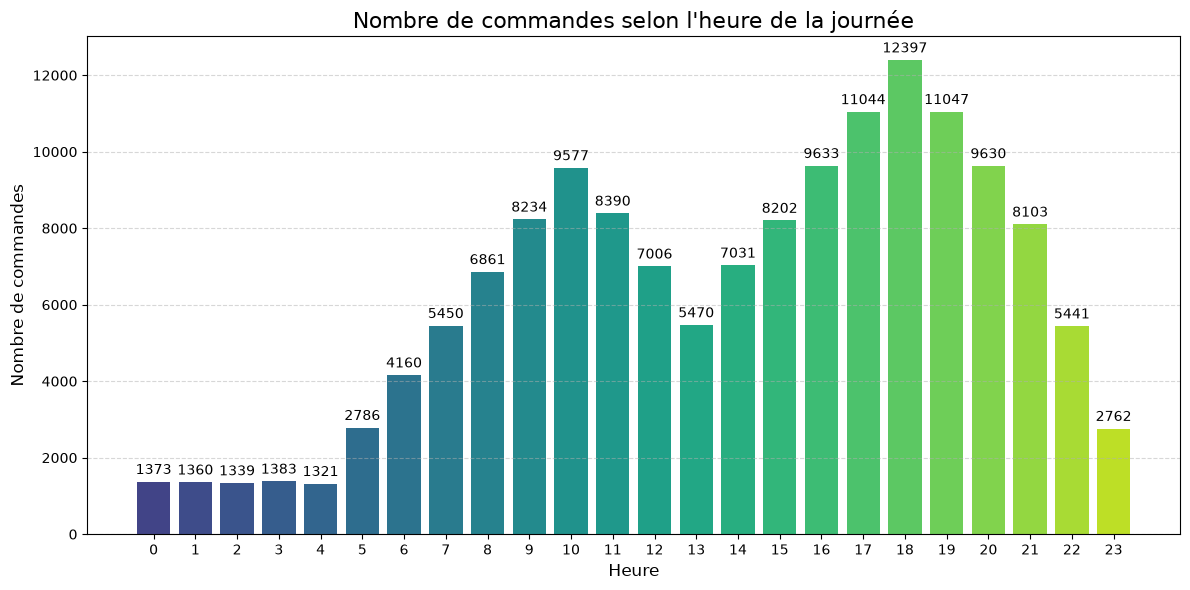

In [1486]:
import matplotlib.pyplot as plt
import numpy as np

# Conversion de Time en datetime si nécessaire
df["Time"] = pd.to_datetime(
    df["Time"],
    errors="coerce"
)

# Extraire l'heure
df["Hour"] = df["Time"].dt.hour

# Compter les commandes par heure
commandes_heure = (
    df["Hour"]
    .value_counts()
    .sort_index()
)

# Création du graphique
plt.figure(figsize=(12, 6))

# Couleurs en dégradé
couleurs = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(commandes_heure))
)

plt.bar(
    commandes_heure.index,
    commandes_heure.values,
    color=couleurs
)

# Ajouter les valeurs au-dessus des barres
for heure, valeur in zip(
    commandes_heure.index,
    commandes_heure.values
):
    plt.text(
        heure,
        valeur + 200,
        str(valeur),
        ha="center",
        fontsize=10
    )

plt.title(
    "Nombre de commandes selon l'heure de la journée",
    fontsize=16
)

plt.xlabel(
    "Heure",
    fontsize=12
)

plt.ylabel(
    "Nombre de commandes",
    fontsize=12
)

plt.xticks(
    range(24)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

# Modes de paiement les plus  utilisés #

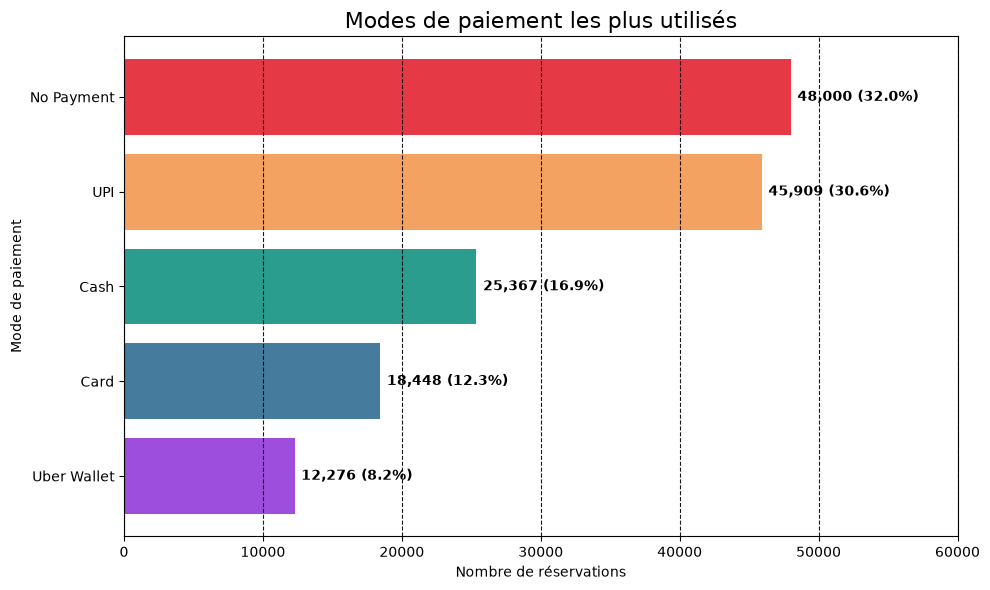

In [1487]:
import matplotlib.pyplot as plt

# Comptage des modes de paiement
payment = (
    df["Payment Method"]
    .value_counts()
    .sort_values(ascending=True)
)

# Calcul des pourcentages
pourcentages = (
    payment / payment.sum() * 100
)

# Couleurs
couleurs = {
    "Card": "#457B9D",
    "Cash": "#2A9D8F",
    "UPI": "#F4A261",
    "Uber Wallet": "#9D4EDD",
    "No Payment": "#E63946"
}

bar_colors = [
    couleurs.get(mode, "gray")
    for mode in payment.index
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    payment.index,
    payment.values,
    color=bar_colors
)

# Affichage des valeurs et pourcentages
for i, bar in enumerate(bars):
    largeur = bar.get_width()

    plt.text(
        largeur + payment.max()*0.01,
        bar.get_y() + bar.get_height()/2,
        f"{int(largeur):,} ({pourcentages.iloc[i]:.1f}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Marge à droite
plt.xlim(
    0,
    payment.max()*1.25
)

plt.title(
    "Modes de paiement les plus utilisés",
    fontsize=16
)

plt.xlabel(
    "Nombre de réservations"
)

plt.ylabel(
    "Mode de paiement"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.9,
    color="black"
)

plt.tight_layout()
plt.show()

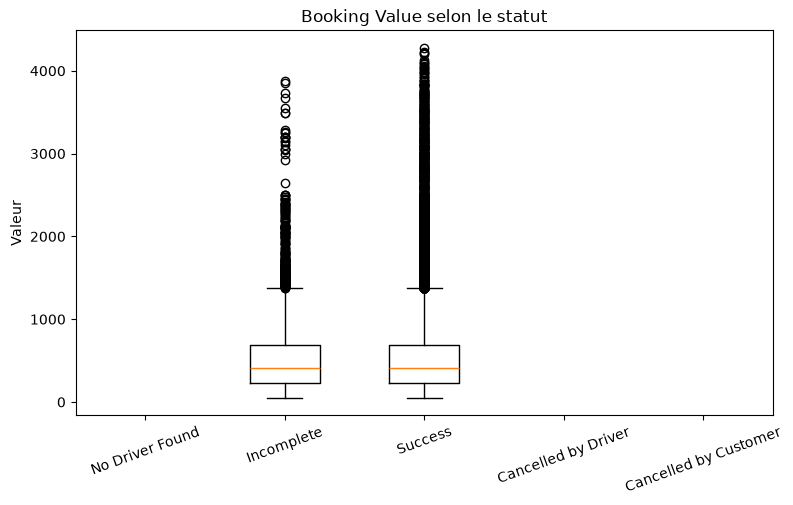

In [1488]:
data = []
labels= []
for statut in df["Booking Status"].unique():
    data.append(
        df[df["Booking Status"] == statut]["Booking Value"].dropna()
    )

plt.figure(figsize=(9,5))

plt.boxplot(data,
            tick_labels=df["Booking Status"].unique())

plt.xticks(rotation=20)

plt.title("Booking Value selon le statut")

plt.ylabel("Valeur")

plt.show()

# Répartition des notes des chauffeurs #

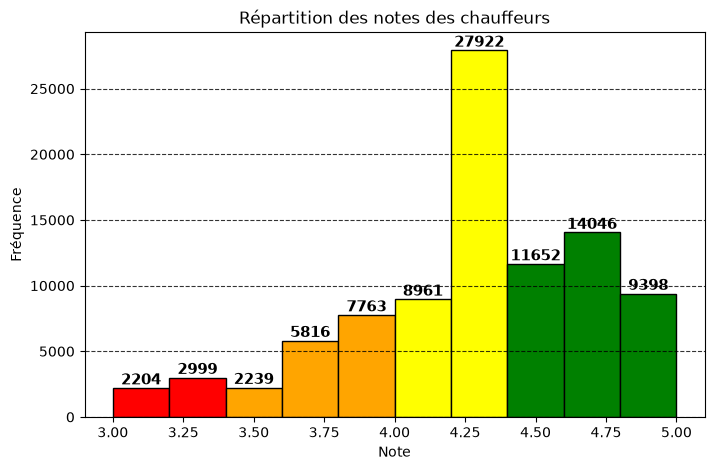

In [1489]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Driver Ratings"].dropna(),
    bins=10,
    edgecolor="black"
)

# Couleur des barres selon la note
for i in range(len(patches)):
    centre = (bins[i] + bins[i+1]) / 2

    if centre < 3.5:
        patches[i].set_facecolor("red")      # Mauvaise note
    elif centre < 4.0:
        patches[i].set_facecolor("orange")   # Note moyenne
    elif centre < 4.5:
        patches[i].set_facecolor("yellow")   # Bonne note
    else:
        patches[i].set_facecolor("green")    # Excellente note

plt.title("Répartition des notes des chauffeurs")
plt.xlabel("Note")
plt.ylabel("Fréquence")

plt.grid(axis="y",
         linestyle="--",
         alpha=0.8,
         color="black")
for count, patch in zip(n, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

plt.show()

# Répartition des notes des clients #

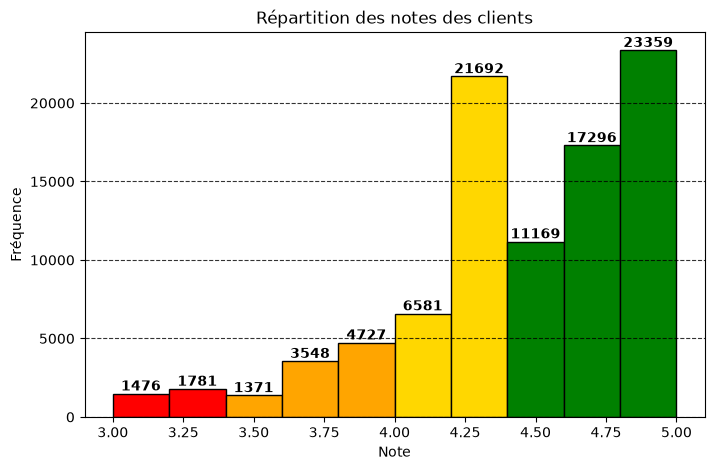

In [1490]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

n, bins, patches = plt.hist(
    df["Customer Rating"].dropna(),
    bins=10,
    edgecolor="black"
)

# Coloration des barres selon la note
for i in range(len(patches)):
    centre = (bins[i] + bins[i+1]) / 2

    if centre < 3.5:
        patches[i].set_facecolor("red")
    elif centre < 4.0:
        patches[i].set_facecolor("orange")
    elif centre < 4.5:
        patches[i].set_facecolor("gold")
    else:
        patches[i].set_facecolor("green")

plt.title("Répartition des notes des clients")
plt.xlabel("Note")
plt.ylabel("Fréquence")
plt.grid(axis="y", linestyle="--", alpha=0.8, color ="black")

for count, patch in zip(n, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )
plt.show()

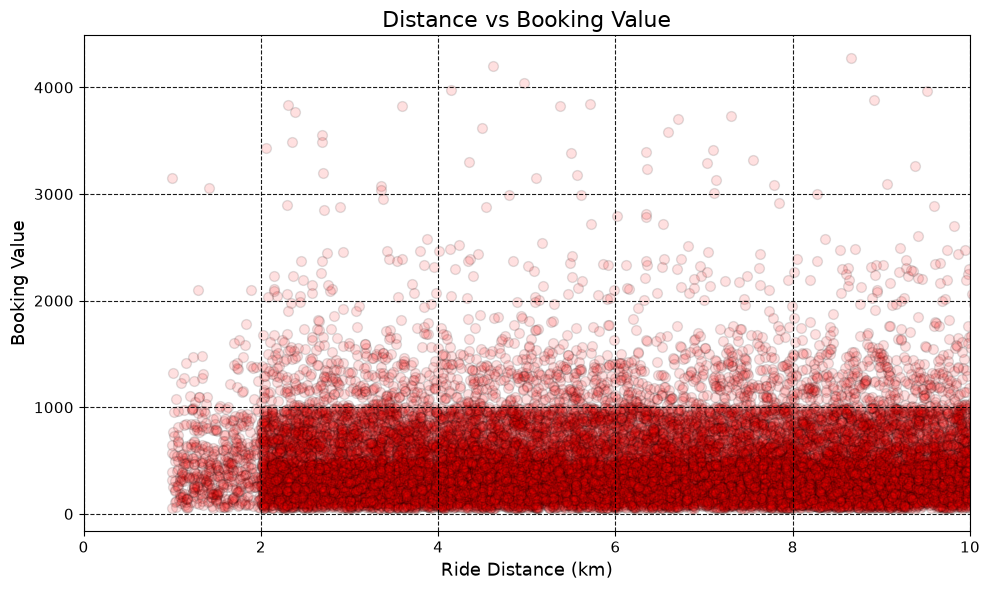

In [1491]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Ride Distance"],
    df["Booking Value"],
    alpha=0.12,
    color="red",
    s=50,               # Taille des points
    edgecolors="black", # Contour des points
    linewidth=1
)

plt.title("Distance vs Booking Value", fontsize=16)
plt.xlabel("Ride Distance (km)", fontsize=13)
plt.ylabel("Booking Value", fontsize=13)

# Taille des graduations
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Afficher uniquement les distances entre 0 et 10
plt.xlim(0, 10)

plt.grid(True, linestyle="--", alpha=0.9, color= "black")

plt.tight_layout()
plt.show()

# Répartitions des valeurs des réservations selon l'heure #

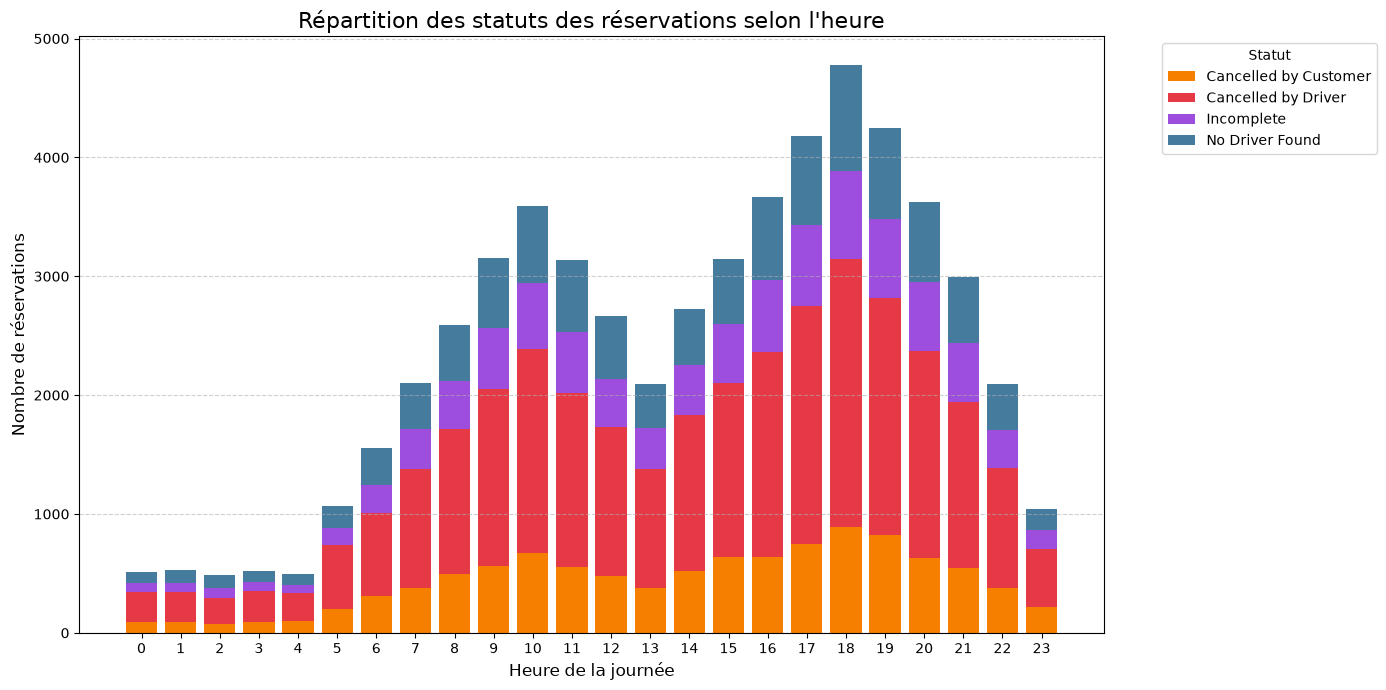

In [1492]:
import pandas as pd
import matplotlib.pyplot as plt

# Conversion de Time en datetime si nécessaire
df["Time"] = pd.to_datetime(
    df["Time"],
    errors="coerce"
)

# Création de la colonne heure
df["Hour"] = df["Time"].dt.hour

# Tableau croisé heure / statut
statut_heure = pd.crosstab(
    df["Hour"],
    df["Booking Status"]
)

# Réorganiser les colonnes pour un affichage logique
ordre_statuts = [
    "Completed",
    "Cancelled by Customer",
    "Cancelled by Driver",
    "Incomplete",
    "No Driver Found"
]

# Garder uniquement les statuts présents
ordre_statuts = [
    s for s in ordre_statuts
    if s in statut_heure.columns
]

statut_heure = statut_heure[ordre_statuts]


# Couleurs associées aux statuts
couleurs = {
    "Completed": "#2A9D8F",
    "Cancelled by Customer": "#F77F00",
    "Cancelled by Driver": "#E63946",
    "Incomplete": "#9D4EDD",
    "No Driver Found": "#457B9D"
}


# Création du graphique
plt.figure(figsize=(14,7))

bottom = None

for statut in statut_heure.columns:

    plt.bar(
        statut_heure.index,
        statut_heure[statut],
        bottom=bottom,
        label=statut,
        color=couleurs.get(statut, "gray")
    )

    if bottom is None:
        bottom = statut_heure[statut]
    else:
        bottom = bottom + statut_heure[statut]


plt.title(
    "Répartition des statuts des réservations selon l'heure",
    fontsize=16
)

plt.xlabel(
    "Heure de la journée",
    fontsize=12
)

plt.ylabel(
    "Nombre de réservations",
    fontsize=12
)

plt.xticks(
    range(24)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.legend(
    title="Statut",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# Temps d'attente moyen pour l'arrivée d'un véhicule et  d'un conducteur #

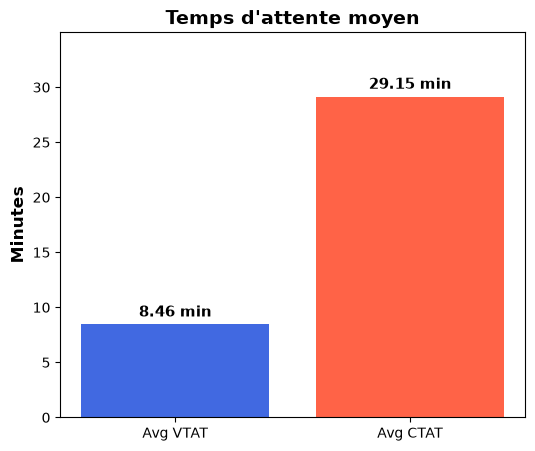

In [1493]:
import matplotlib.pyplot as plt

moyennes = [
    df["Avg VTAT"].mean(),
    df["Avg CTAT"].mean()
]

labels = ["Avg VTAT", "Avg CTAT"]

plt.figure(figsize=(6,5))

bars = plt.bar(
    labels,
    moyennes,
    color=["royalblue", "tomato"]
)

# Affichage des valeurs au-dessus des barres
plt.bar_label(
    bars,
    fmt="%.2f min",      # 2 décimales + unité
    fontsize=11,
    fontweight="bold",
    padding=3
)

plt.ylabel("Minutes", fontsize=12, fontweight="bold")
plt.title("Temps d'attente moyen", fontsize=14, fontweight="bold")
plt.ylim(0, max(moyennes) * 1.2)

plt.show()

# Top 15 des zones avec le plus fort taux d'échec (avec un minimum de 100 réservations) #

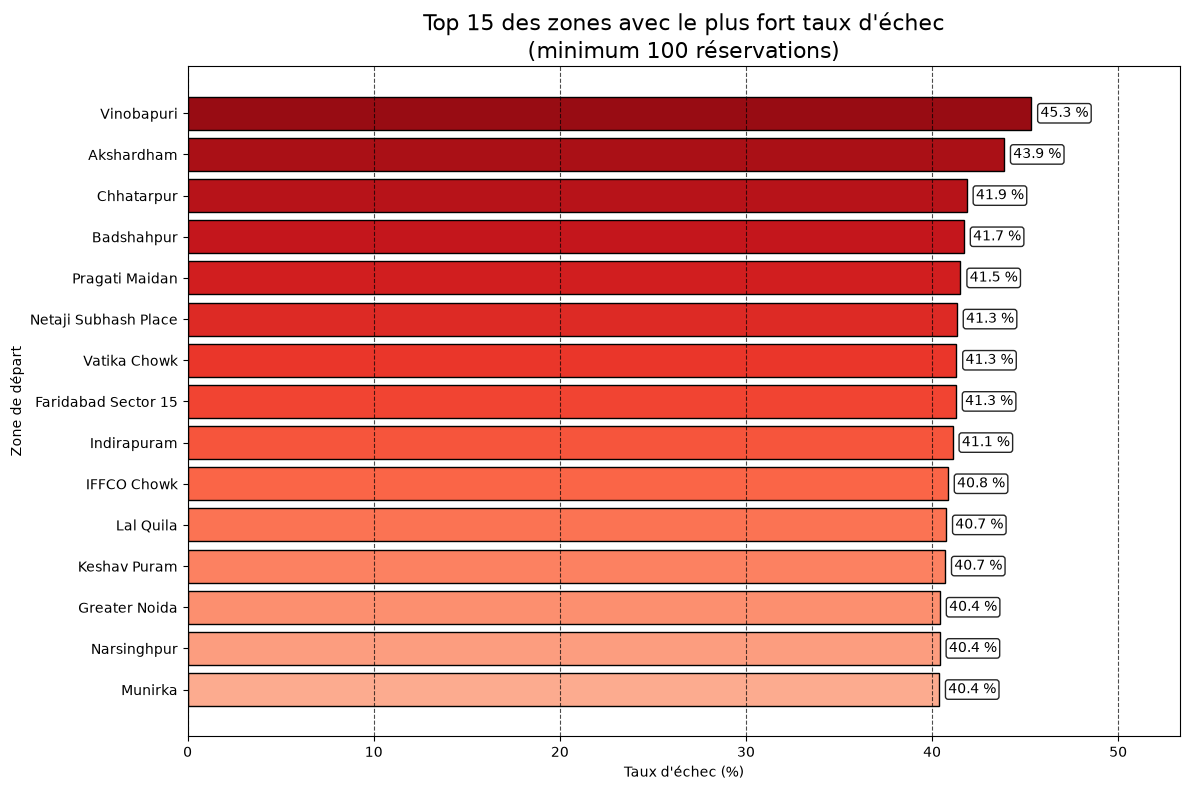

In [1494]:
import matplotlib.pyplot as plt
import numpy as np

# Nombre minimum de réservations
minimum_reservations = 100

# Nombre total de réservations par zone
reservations = (
    df.groupby("Pickup Location")
    .size()
)

# Statuts considérés comme des échecs
statuts_echec = [
    "Cancelled by Customer",
    "Cancelled by Driver",
    "Incomplete",
    "No Driver Found"
]

# Nombre d'échecs par zone
echecs = (
    df[df["Booking Status"].isin(statuts_echec)]
    .groupby("Pickup Location")
    .size()
)

# Calcul du taux d'échec
taux_echec = (
    (echecs / reservations * 100)
    .fillna(0)
)

# Conserver uniquement les zones avec suffisamment de réservations
taux_echec = (
    taux_echec[reservations >= minimum_reservations]
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

# Couleurs
couleurs = plt.cm.Reds(
    np.linspace(0.3, 0.9, len(taux_echec))
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    taux_echec.index,
    taux_echec.values,
    color=couleurs,
    edgecolor="black"
)

# Marge pour les annotations
ax.set_xlim(0, taux_echec.max() + 8)

# Affichage des pourcentages avec bbox
for bar in bars:
    largeur = bar.get_width()

    ax.text(
        largeur + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{largeur:.1f} %",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

ax.set_title(
    f"Top 15 des zones avec le plus fort taux d'échec\n(minimum {minimum_reservations} réservations)",
    fontsize=16
)

ax.set_xlabel("Taux d'échec (%)")
ax.set_ylabel("Zone de départ")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
    color="black"
)

plt.tight_layout()
plt.show()

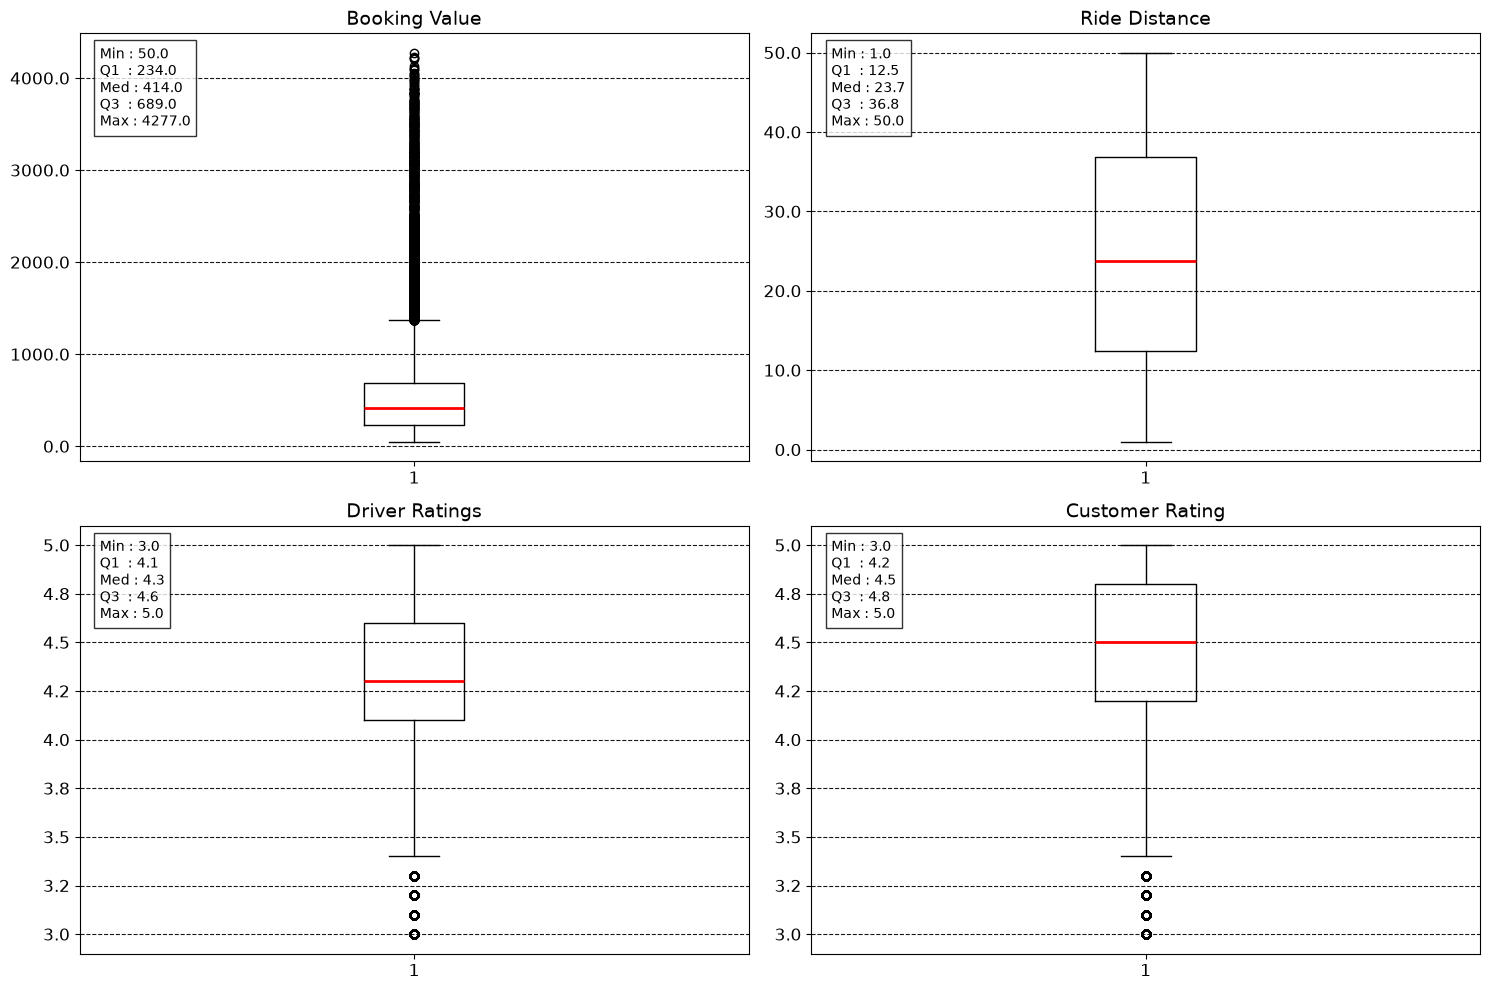

In [1495]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

colonnes = [
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

for axes, colonne in zip(ax.flat, colonnes):

    valeurs = df[colonne].dropna()

    axes.boxplot(
        valeurs,
        medianprops={
            "color": "red",
            "linewidth": 2
        }
    )

    axes.set_title(colonne, fontsize=14)
    axes.tick_params(labelsize=12)
    axes.grid(axis="y", linestyle="--", alpha=0.9, color="black")
    axes.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    # Calcul des statistiques
    mini = valeurs.min()
    q1 = valeurs.quantile(0.25)
    med = valeurs.median()
    q3 = valeurs.quantile(0.75)
    maxi = valeurs.max()

    # Texte des statistiques
    texte = (
        f"Min : {mini:.1f}\n"
        f"Q1  : {q1:.1f}\n"
        f"Med : {med:.1f}\n"
        f"Q3  : {q3:.1f}\n"
        f"Max : {maxi:.1f}"
    )

    # Affichage dans un encadré
    axes.text(
        0.03,
        0.97,
        texte,
        transform=axes.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox={
            "facecolor": "white",
            "edgecolor": "black",
            "alpha": 0.8
        }
    )

plt.tight_layout()
plt.show()

# Distribution des données avec une courbe de Gauss concernant la valeur de réservation #

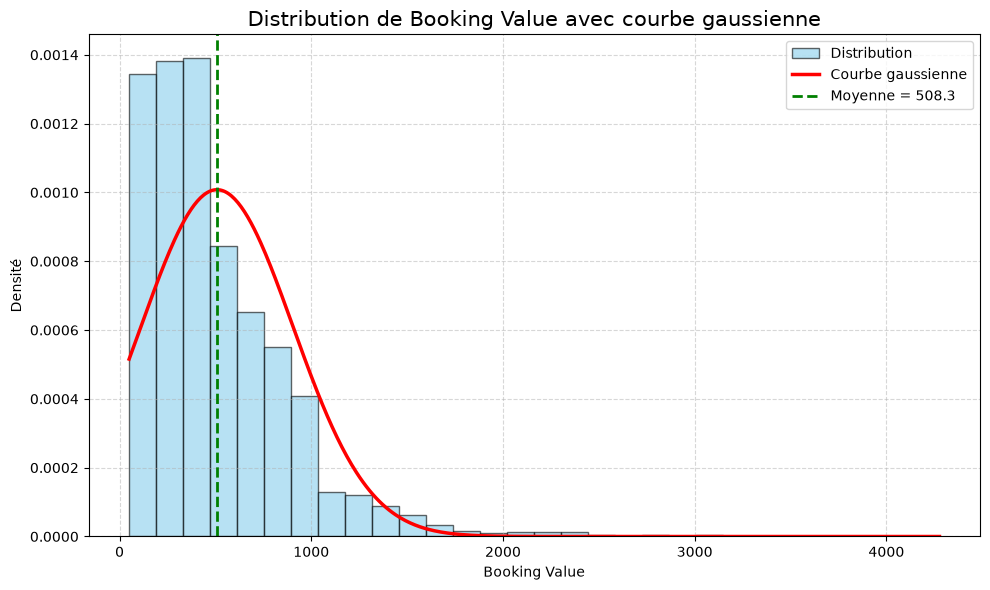

In [1496]:
import matplotlib.pyplot as plt
import numpy as np

# Garder uniquement les valeurs positives
valeurs = df.loc[
    df["Booking Value"] > 0,
    "Booking Value"
]

# Calcul de la moyenne et de l'écart-type
moyenne = valeurs.mean()
ecart_type = valeurs.std()

# Axe des x
x = np.linspace(
    valeurs.min(),
    valeurs.max(),
    500
)

# Fonction de densité gaussienne
gauss = (
    1
    / (ecart_type * np.sqrt(2 * np.pi))
) * np.exp(
    -((x - moyenne) ** 2)
    / (2 * ecart_type ** 2)
)

plt.figure(figsize=(10, 6))

# Histogramme normalisé
plt.hist(
    valeurs,
    bins=30,
    density=True,
    alpha=0.6,
    color="skyblue",
    edgecolor="black",
    label="Distribution"
)

# Courbe gaussienne
plt.plot(
    x,
    gauss,
    color="red",
    linewidth=2.5,
    label="Courbe gaussienne"
)

# Ligne de la moyenne
plt.axvline(
    moyenne,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Moyenne = {moyenne:.1f}"
)

plt.title(
    "Distribution de Booking Value avec courbe gaussienne",
    fontsize=15
)

plt.xlabel("Booking Value")
plt.ylabel("Densité")

plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.show()

# Courbe KDE pour la valeur de réservation #

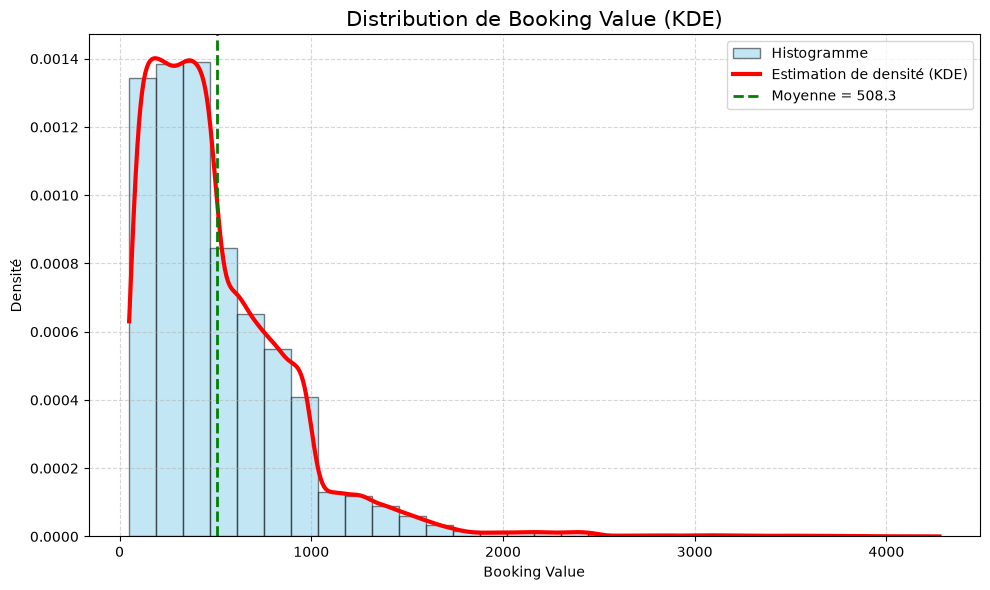

In [1497]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.stats import gaussian_kde

# Garder uniquement les valeurs positives
valeurs = df.loc[
    df["Booking Value"] > 0,
    "Booking Value"
]

# Estimation de densité par noyau
kde = gaussian_kde(valeurs)

# Axe des x
x = np.linspace(
    valeurs.min(),
    valeurs.max(),
    500
)

# Densité estimée
y = kde(x)

plt.figure(figsize=(10, 6))

# Histogramme normalisé
plt.hist(
    valeurs,
    bins=30,
    density=True,
    alpha=0.5,
    color="skyblue",
    edgecolor="black",
    label="Histogramme"
)

# Courbe KDE
plt.plot(
    x,
    y,
    color="red",
    linewidth=3,
    label="Estimation de densité (KDE)"
)

# Moyenne
plt.axvline(
    valeurs.mean(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Moyenne = {valeurs.mean():.1f}"
)

plt.title(
    "Distribution de Booking Value (KDE)",
    fontsize=15
)

plt.xlabel("Booking Value")
plt.ylabel("Densité")

plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.show()


# Courbes KDE (Kernel Density Estimation) pour la distance parcourue, le temps moyen d'attente d'un consommateur et du conducteur #

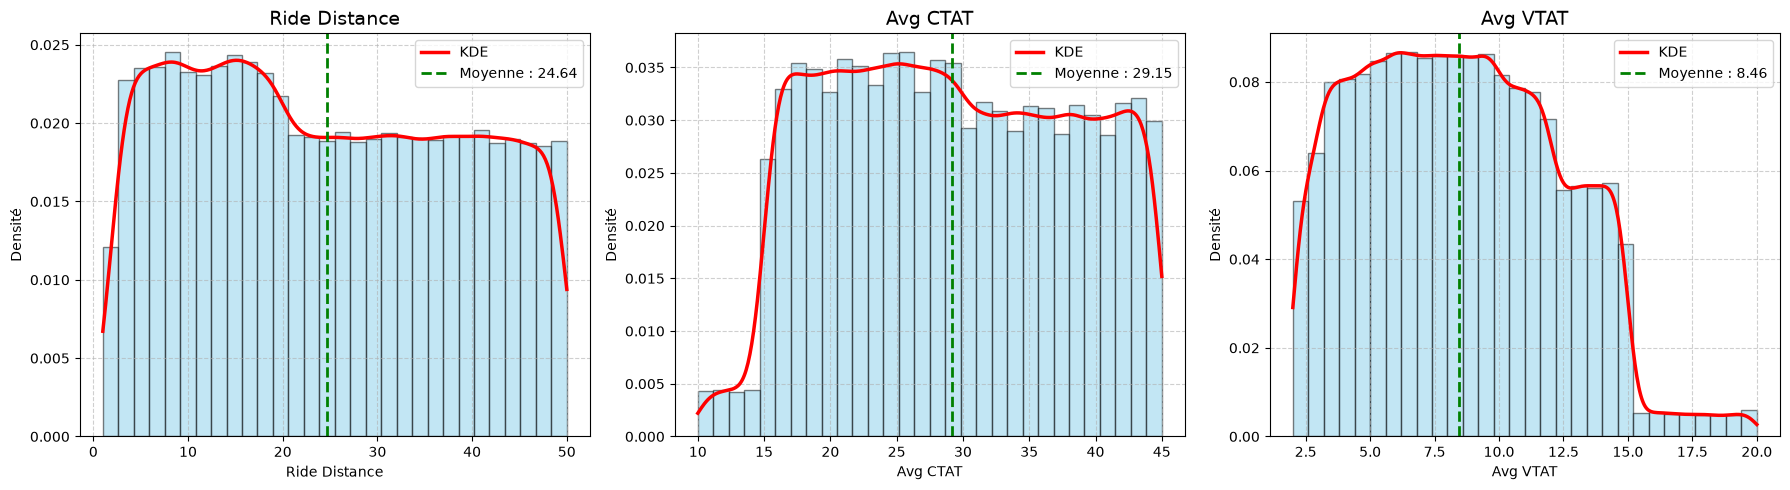

In [1498]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

colonnes = [
    "Ride Distance",
    "Avg CTAT",
    "Avg VTAT"
]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for axes, colonne in zip(ax, colonnes):

    # Suppression des NaN et des valeurs nulles
    valeurs = df.loc[
        df[colonne] > 0,
        colonne
    ].dropna()

    # Calcul de la KDE
    kde = gaussian_kde(valeurs)

    x = np.linspace(
        valeurs.min(),
        valeurs.max(),
        500
    )

    y = kde(x)

    # Histogramme
    axes.hist(
        valeurs,
        bins=30,
        density=True,
        alpha=0.5,
        color="skyblue",
        edgecolor="black"
    )

    # Courbe KDE
    axes.plot(
        x,
        y,
        color="red",
        linewidth=2.5,
        label="KDE"
    )

    # Moyenne
    axes.axvline(
        valeurs.mean(),
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Moyenne : {valeurs.mean():.2f}"
    )

    axes.set_title(colonne, fontsize=14)
    axes.set_xlabel(colonne)
    axes.set_ylabel("Densité")
    axes.grid(
        linestyle="--",
        alpha=0.6
    )
    axes.legend()

plt.tight_layout()
plt.show()

# Répartition des raisons d'annulation des chauffeurs #

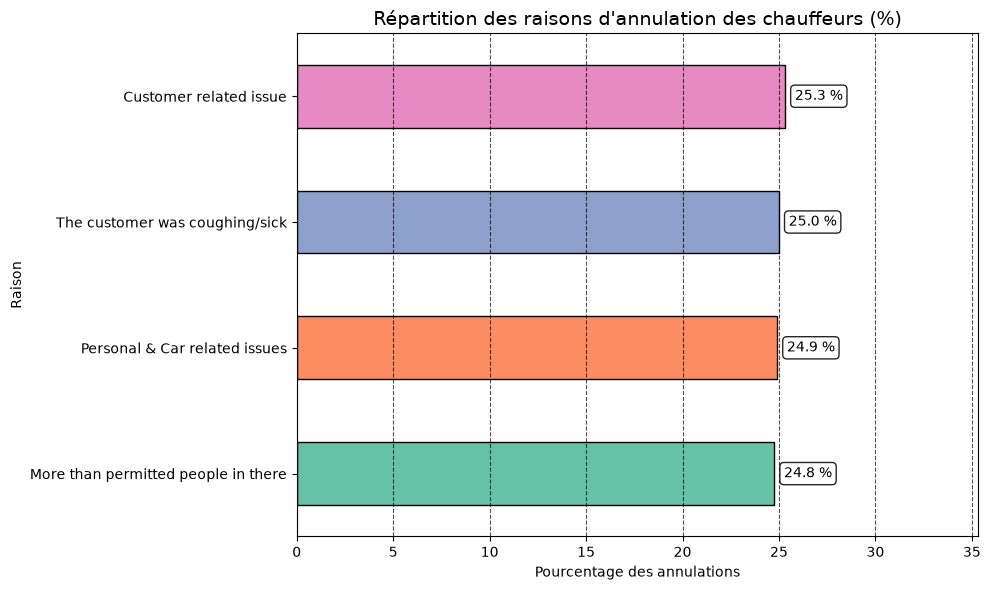

In [1499]:
import matplotlib.pyplot as plt


raisons_chauffeurs_pct = (
    df[
        (df["Driver Cancellation Reason"].notna()) &
        (df["Driver Cancellation Reason"] != "Not Applicable")
    ]
    ["Driver Cancellation Reason"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)


# Palette de couleurs
couleurs = plt.cm.Set2(range(len(raisons_chauffeurs_pct)))


# Création du graphique
fig, ax = plt.subplots(figsize=(10,6))


raisons_chauffeurs_pct.plot(
    kind="barh",
    edgecolor="black",
    color=couleurs,
    ax=ax
)


plt.title(
    "Répartition des raisons d'annulation des chauffeurs (%)",
    fontsize=14
)

plt.xlabel("Pourcentage des annulations")
plt.ylabel("Raison")


# Ajouter une marge à droite pour les annotations
max_valeur = raisons_chauffeurs_pct.max()
ax.set_xlim(0, max_valeur + 10)


# Valeurs avec bbox
for i, valeur in enumerate(raisons_chauffeurs_pct):
    ax.text(
        valeur + 0.5,
        i,
        f"{valeur:.1f} %",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


# Pointillés verticaux sur l'axe X
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.tight_layout()
plt.show()

# Répartition des raison d'annulation des clients #

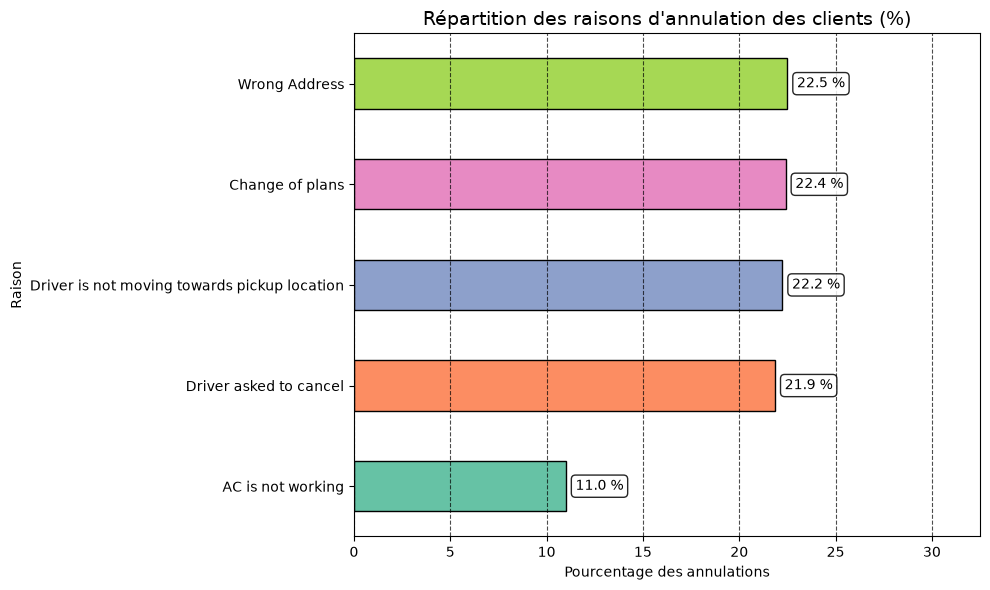

In [1500]:
import matplotlib.pyplot as plt


raisons_clients_pct = (
    df[
        (df["Reason for cancelling by Customer"].notna()) &
        (df["Reason for cancelling by Customer"] != "Not Applicable")
    ]
    ["Reason for cancelling by Customer"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)


# Palette de couleurs
couleurs = plt.cm.Set2(range(len(raisons_clients_pct)))


# Création du graphique
fig, ax = plt.subplots(figsize=(10,6))


raisons_clients_pct.plot(
    kind="barh",
    edgecolor="black",
    color=couleurs,
    ax=ax
)


plt.title(
    "Répartition des raisons d'annulation des clients (%)",
    fontsize=14
)

plt.xlabel("Pourcentage des annulations")
plt.ylabel("Raison")


# Ajouter une marge à droite pour les annotations
max_valeur = raisons_clients_pct.max()
ax.set_xlim(0, max_valeur + 10)


# Valeurs avec bbox
for i, valeur in enumerate(raisons_clients_pct):
    ax.text(
        valeur + 0.5,
        i,
        f"{valeur:.1f} %",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


# Pointillés verticaux sur l'axe X
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.tight_layout()
plt.show()

# Répartition des types de véhicules les plus utilisés #

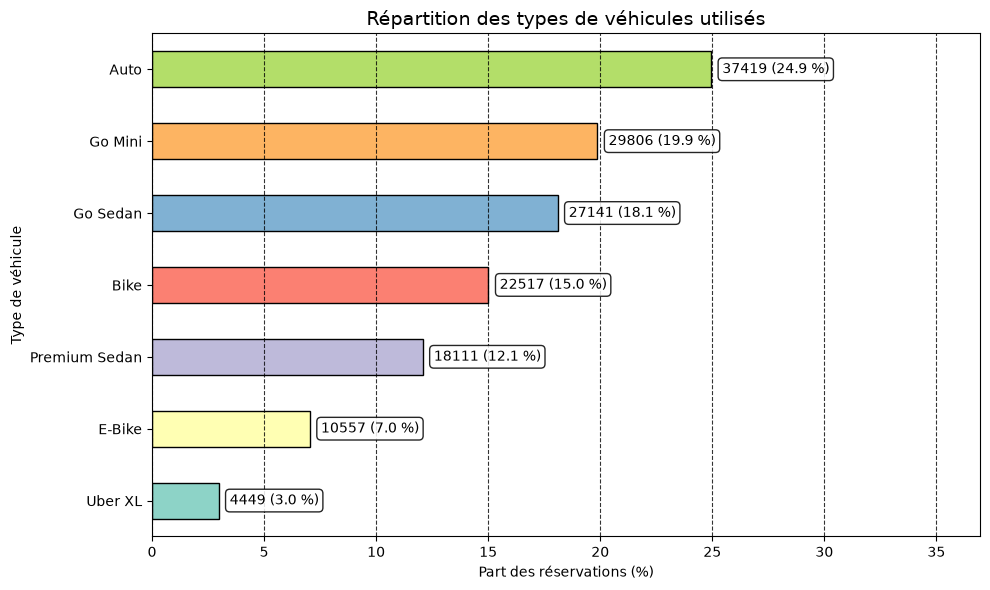

In [1501]:
import matplotlib.pyplot as plt


# Nombre de réservations par type de véhicule
types_vehicules = (
    df["Vehicle Type"]
    .value_counts()
    .sort_values()
)


# Pourcentage
types_vehicules_pct = (
    types_vehicules
    .div(types_vehicules.sum())
    .mul(100)
)


# Couleurs
couleurs = plt.cm.Set3(range(len(types_vehicules_pct)))


# Création du graphique
fig, ax = plt.subplots(figsize=(10,6))


types_vehicules_pct.plot(
    kind="barh",
    edgecolor="black",
    color=couleurs,
    ax=ax
)


plt.title(
    "Répartition des types de véhicules utilisés",
    fontsize=14
)

plt.xlabel("Part des réservations (%)")
plt.ylabel("Type de véhicule")


# Ajout d'une marge à droite pour les annotations
max_valeur = types_vehicules_pct.max()
ax.set_xlim(0, max_valeur + 12)


# Affichage nombre + pourcentage avec bbox
for i, (pourcentage, nombre) in enumerate(
    zip(types_vehicules_pct, types_vehicules)
):
    ax.text(
        pourcentage + 0.5,
        i,
        f"{nombre} ({pourcentage:.1f} %)",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            edgecolor="black",
            facecolor="white",
            alpha=0.85
        )
    )


ax.grid(
    axis="x",
    alpha=0.8,
    color="black",
    linestyle="--",
    
)

plt.tight_layout()
plt.show()

# Répartition des raisons des courses incomplètes #

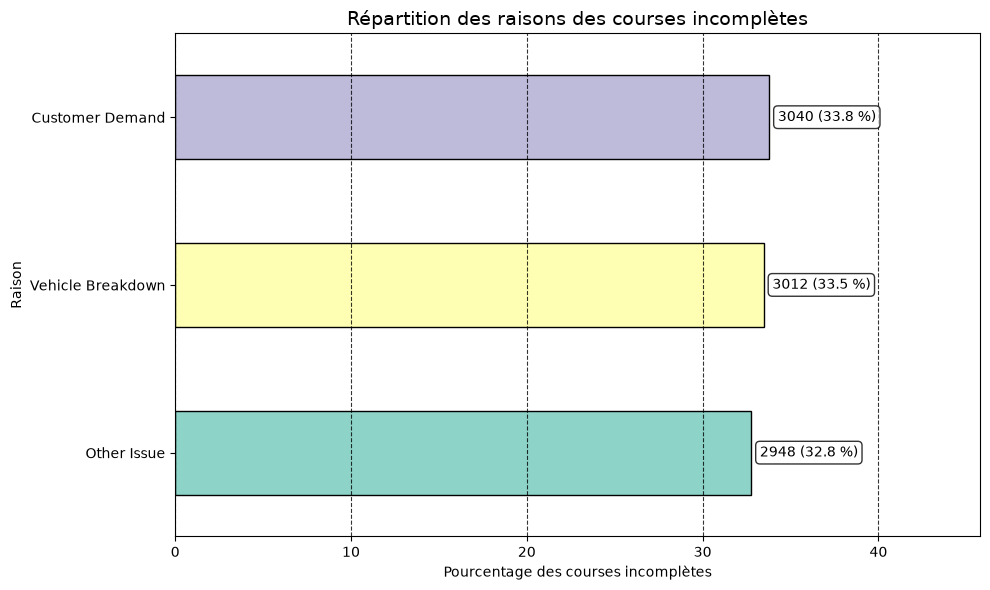

In [1502]:
import matplotlib.pyplot as plt


# Raisons des courses incomplètes (nombre)
raisons_incomplete = (
    df[df["Incomplete Rides"] == 1]
    ["Incomplete Rides Reason"]
    .dropna()
    .value_counts()
    .sort_values()
)


# Pourcentage
raisons_incomplete_pct = (
    raisons_incomplete
    .div(raisons_incomplete.sum())
    .mul(100)
)


# Palette de couleurs
couleurs = plt.cm.Set3(range(len(raisons_incomplete_pct)))


# Création du graphique
fig, ax = plt.subplots(figsize=(10,6))

raisons_incomplete_pct.plot(
    kind="barh",
    edgecolor="black",
    color=couleurs,
    ax=ax
)


plt.title(
    "Répartition des raisons des courses incomplètes",
    fontsize=14
)

plt.xlabel("Pourcentage des courses incomplètes")
plt.ylabel("Raison")


# Marge pour éviter que les annotations sortent
max_valeur = raisons_incomplete_pct.max()
ax.set_xlim(0, max_valeur + 12)


# Affichage des valeurs avec bbox
for i, (pourcentage, nombre) in enumerate(
    zip(raisons_incomplete_pct, raisons_incomplete)
):
    ax.text(
        pourcentage + 0.5,
        i,
        f"{nombre} ({pourcentage:.1f} %)",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            edgecolor="black",
            facecolor="white",
            alpha=0.8
        )
    )


ax.grid(
    axis="x",
    alpha=0.8,
    color="black",
    linestyle="--",
)

plt.tight_layout()
plt.show()

# Répartition des raisons des courses incomplètes (2ème représentation) #

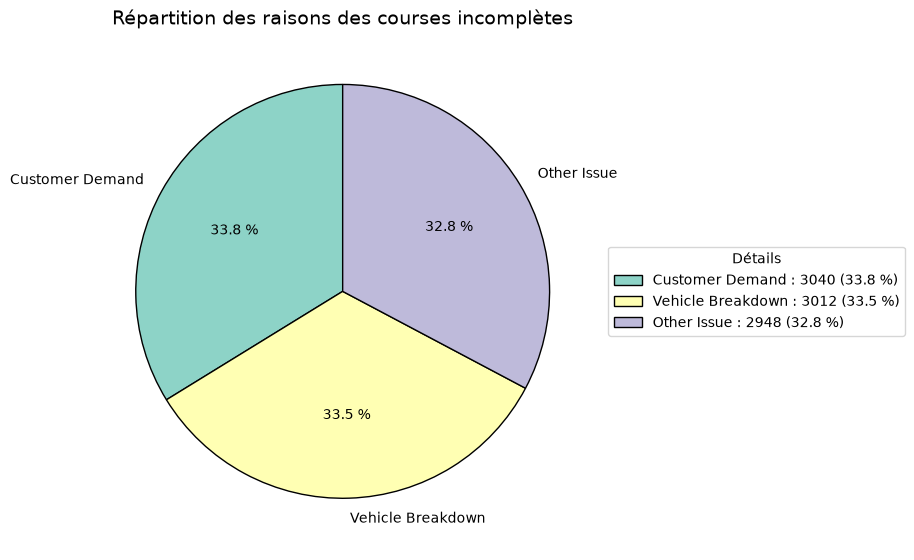

In [1503]:
import matplotlib.pyplot as plt


# Raisons des courses incomplètes
raisons_incomplete = (
    df[df["Incomplete Rides"] == 1]
    ["Incomplete Rides Reason"]
    .dropna()
    .value_counts()
)


# Pourcentage
raisons_incomplete_pct = (
    raisons_incomplete
    .div(raisons_incomplete.sum())
    .mul(100)
)


# Couleurs
couleurs = plt.cm.Set3(range(len(raisons_incomplete_pct)))


# Création du camembert
fig, ax = plt.subplots(figsize=(9,9))


wedges, texts, autotexts = ax.pie(
    raisons_incomplete_pct,
    labels=raisons_incomplete_pct.index,
    autopct=lambda pct: f"{pct:.1f} %",
    startangle=90,
    colors=couleurs,
    wedgeprops={
        "edgecolor": "black"
    }
)


# Ajout des valeurs dans une légende
legende = [
    f"{raison} : {nombre} ({pourcentage:.1f} %)"
    for raison, nombre, pourcentage in zip(
        raisons_incomplete.index,
        raisons_incomplete,
        raisons_incomplete_pct
    )
]


ax.legend(
    wedges,
    legende,
    title="Détails",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)


plt.title(
    "Répartition des raisons des courses incomplètes",
    fontsize=14
)


plt.tight_layout()
plt.show()

# Top 10 des lieux avec le plus de commandes #

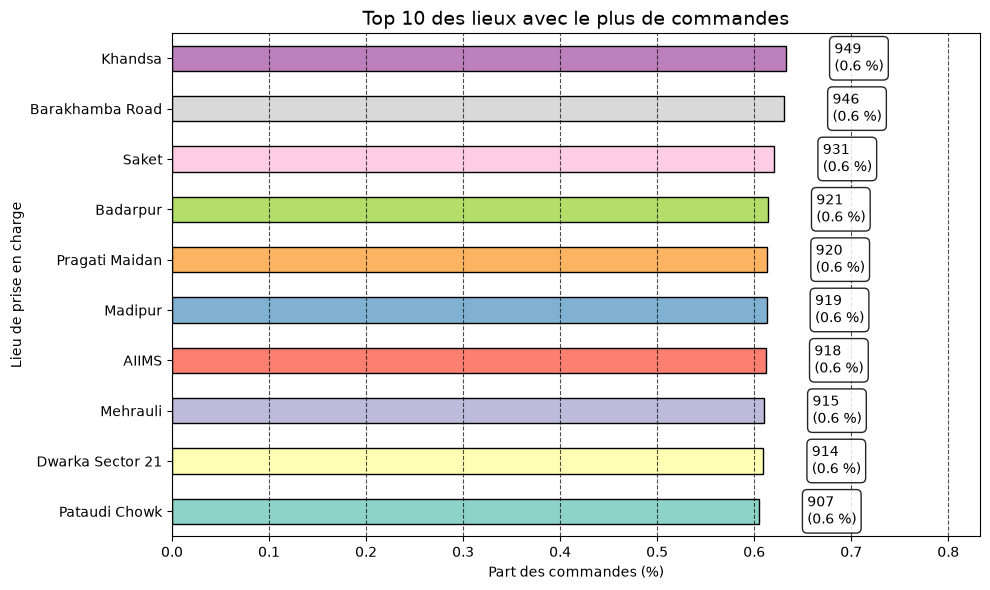

In [1504]:
import matplotlib.pyplot as plt


# Top 10 des lieux avec le plus de commandes
top10_locations = (
    df["Pickup Location"]
    .value_counts()
    .head(10)
    .sort_values()
)


# Pourcentage du total
top10_locations_pct = (
    top10_locations
    .div(df["Pickup Location"].count())
    .mul(100)
)


# Couleurs
couleurs = plt.cm.Set3(range(len(top10_locations_pct)))


# Création du graphique
fig, ax = plt.subplots(figsize=(10,6))


top10_locations_pct.plot(
    kind="barh",
    edgecolor="black",
    color=couleurs,
    ax=ax
)


plt.title(
    "Top 10 des lieux avec le plus de commandes",
    fontsize=14
)

plt.xlabel("Part des commandes (%)")
plt.ylabel("Lieu de prise en charge")


# Ajouter une marge à droite pour les annotations
max_valeur = top10_locations_pct.max()
ax.set_xlim(0, max_valeur + 0.2)


# Valeurs avec bbox sur deux lignes
for i, (pourcentage, nombre) in enumerate(
    zip(top10_locations_pct, top10_locations)
):
    ax.text(
        pourcentage + 0.05,
        i,
        f"{nombre:,}\n({pourcentage:.1f} %)",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


# Pointillés verticaux
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.tight_layout()
plt.show()

# Analyse des performances par zone (top 10) #

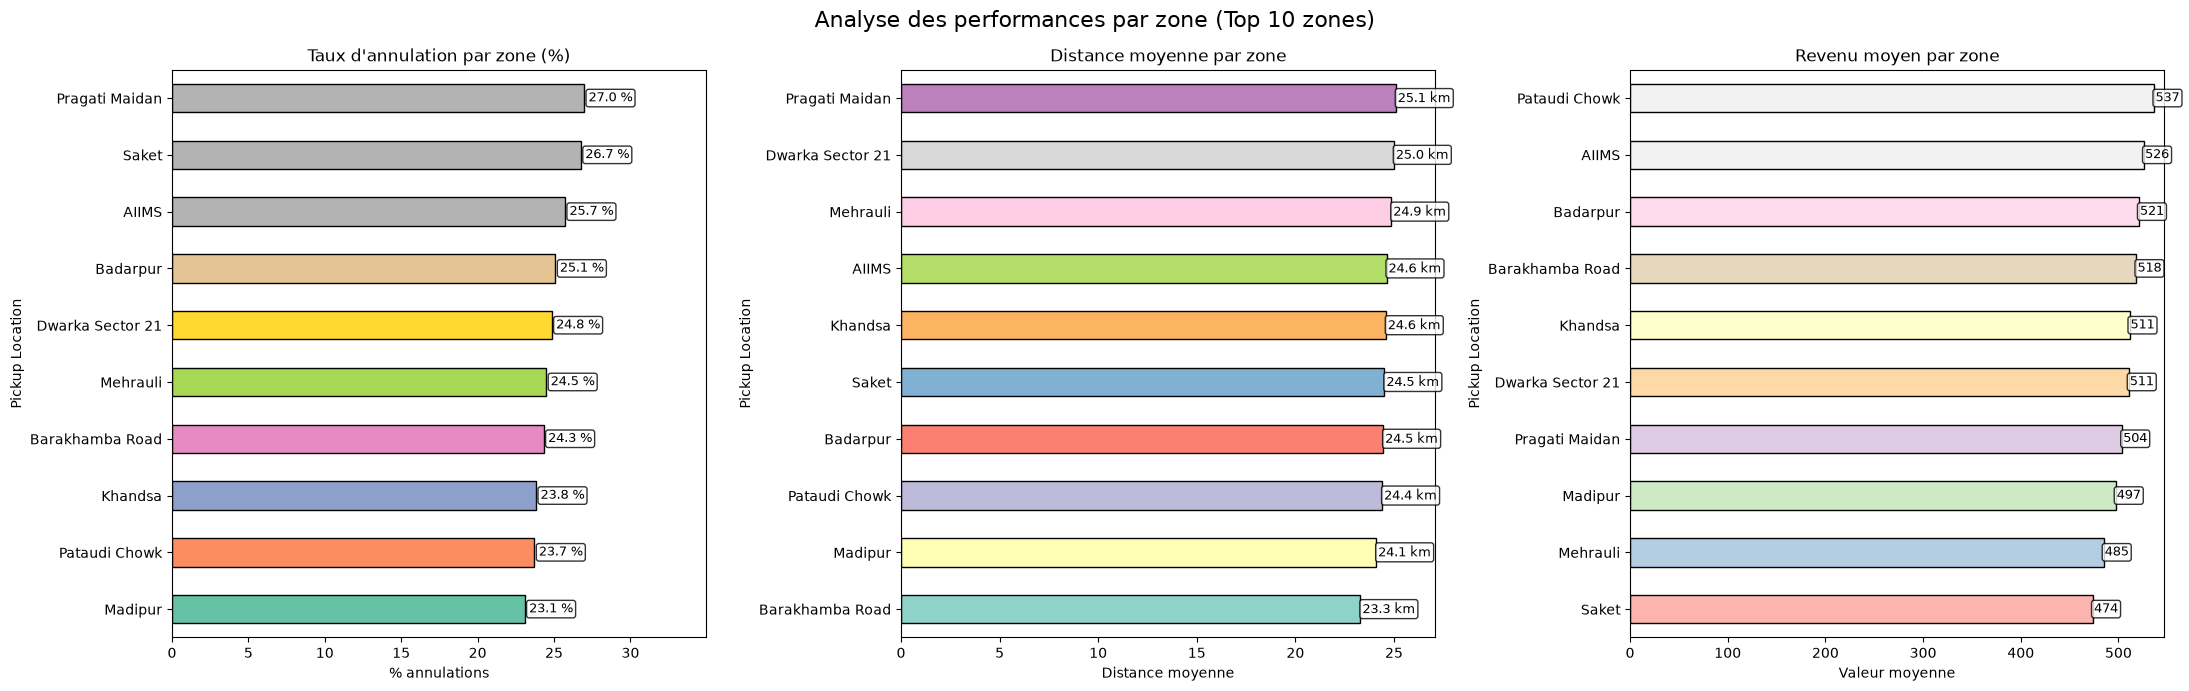

In [1505]:
import matplotlib.pyplot as plt
import pandas as pd


# ==============================
# Sélection des Top 10 zones
# ==============================

top10_zones = (
    df["Pickup Location"]
    .value_counts()
    .head(10)
    .index
)


df_zone = df[
    df["Pickup Location"].isin(top10_zones)
].copy()


# ==============================
# 1) Taux d'annulation par zone
# ==============================

annulation_zone = (
    df_zone.groupby("Pickup Location")
    ["Booking Status"]
    .apply(
        lambda x: (
            x.str.contains("Cancelled", na=False)
            .mean()
            * 100
        )
    )
    .sort_values()
)


# ==============================
# 2) Distance moyenne par zone
# ==============================

distance_zone = (
    df_zone.groupby("Pickup Location")
    ["Ride Distance"]
    .mean()
    .sort_values()
)


# ==============================
# 3) Revenu moyen par zone
# ==============================

revenu_zone = (
    df_zone.groupby("Pickup Location")
    ["Booking Value"]
    .mean()
    .sort_values()
)


# ==============================
# Création des graphiques
# ==============================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22,7)
)


# Couleurs
couleurs1 = plt.cm.Set2(range(len(annulation_zone)))
couleurs2 = plt.cm.Set3(range(len(distance_zone)))
couleurs3 = plt.cm.Pastel1(range(len(revenu_zone)))


# ------------------------------
# Graphique 1 : Annulations
# ------------------------------

annulation_zone.plot(
    kind="barh",
    ax=axes[0],
    color=couleurs1,
    edgecolor="black"
)

axes[0].set_title(
    "Taux d'annulation par zone (%)"
)

axes[0].set_xlabel("% annulations")

axes[0].set_xlim(
    0,
    annulation_zone.max() + 8
)


for i, valeur in enumerate(annulation_zone):
    axes[0].text(
        valeur + 0.3,
        i,
        f"{valeur:.1f} %",
        va="center",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            alpha=0.8
        )
    )


# ------------------------------
# Graphique 2 : Distance
# ------------------------------

distance_zone.plot(
    kind="barh",
    ax=axes[1],
    color=couleurs2,
    edgecolor="black"
)

axes[1].set_title(
    "Distance moyenne par zone"
)

axes[1].set_xlabel("Distance moyenne")

axes[1].set_xlim(
    0,
    distance_zone.max() + 2
)


for i, valeur in enumerate(distance_zone):
    axes[1].text(
        valeur + 0.1,
        i,
        f"{valeur:.1f} km",
        va="center",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            alpha=0.8
        )
    )


# ------------------------------
# Graphique 3 : Revenu
# ------------------------------

revenu_zone.plot(
    kind="barh",
    ax=axes[2],
    color=couleurs3,
    edgecolor="black"
)

axes[2].set_title(
    "Revenu moyen par zone"
)

axes[2].set_xlabel("Valeur moyenne")

axes[2].set_xlim(
    0,
    revenu_zone.max() + 10
)


for i, valeur in enumerate(revenu_zone):
    axes[2].text(
        valeur + 1,
        i,
        f"{valeur:.0f}",
        va="center",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            alpha=0.8,
            
        )
    )


plt.suptitle(
    "Analyse des performances par zone (Top 10 zones)",
    fontsize=16
)

plt.tight_layout()
plt.show()

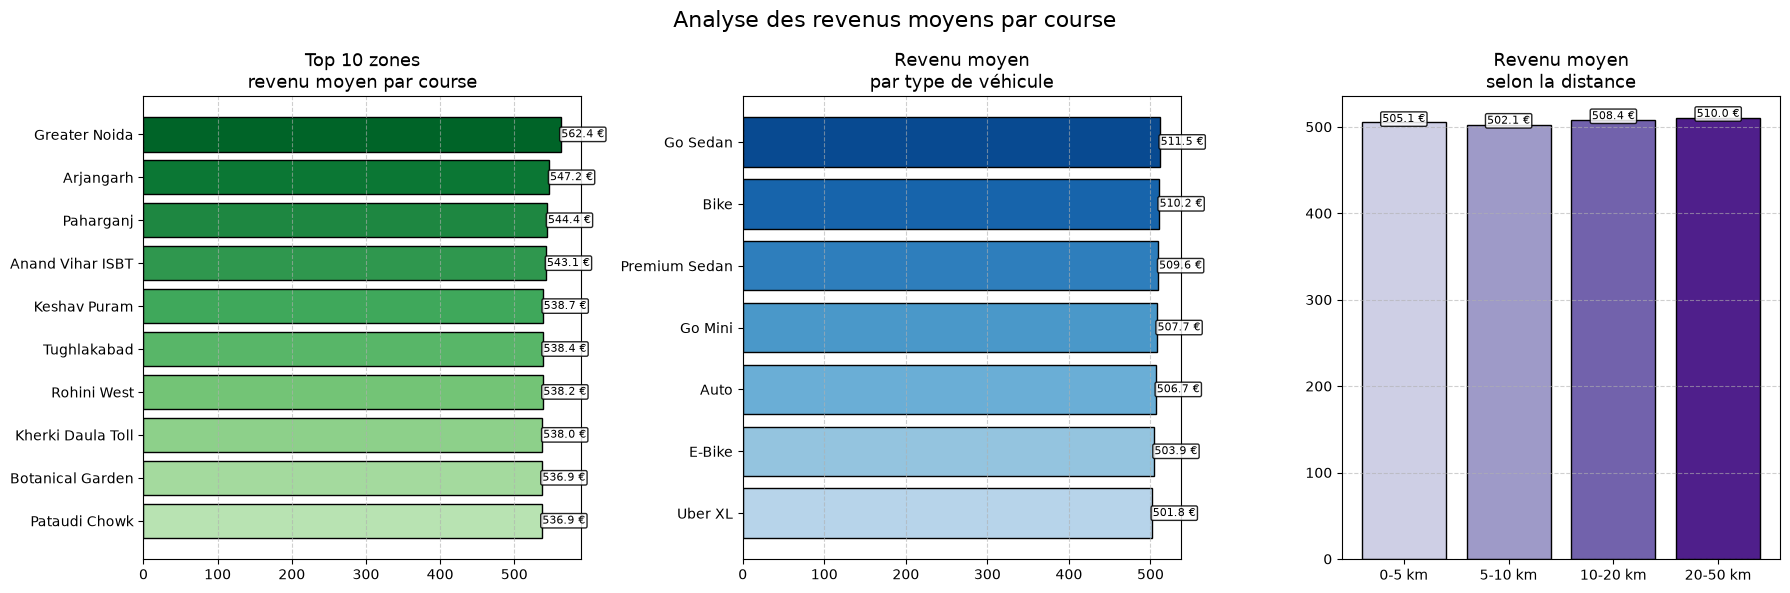

In [1513]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ==============================
# 1) Revenu moyen par zone
# ==============================

revenu_zone = (
    df.groupby("Pickup Location")["Booking Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)


# ==============================
# 2) Revenu moyen par véhicule
# ==============================

revenu_vehicule = (
    df.groupby("Vehicle Type")["Booking Value"]
    .mean()
    .sort_values()
)


# ==============================
# 3) Revenu moyen par distance
# ==============================

df["Distance catégorie"] = pd.cut(
    df["Ride Distance"],
    bins=[0,5,10,20,50,100],
    labels=[
        "0-5 km",
        "5-10 km",
        "10-20 km",
        "20-50 km",
        "+50 km"
    ]
)


revenu_distance = (
    df.groupby(
        "Distance catégorie",
        observed=False
    )["Booking Value"]
    .mean()
    .dropna()
)



# ==============================
# Création des graphiques
# ==============================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,6)
)


# Palettes différentes

couleurs_zone = plt.cm.Greens(
    np.linspace(0.3,0.9,len(revenu_zone))
)

couleurs_vehicule = plt.cm.Blues(
    np.linspace(0.3,0.9,len(revenu_vehicule))
)

couleurs_distance = plt.cm.Purples(
    np.linspace(0.3,0.9,len(revenu_distance))
)



# ==============================
# Graphique 1 : Zones
# ==============================

bars = axes[0].barh(
    revenu_zone.index,
    revenu_zone.values,
    color=couleurs_zone,
    edgecolor="black"
)


axes[0].set_title(
    "Top 10 zones\nrevenu moyen par course",
    fontsize=13
)


for i, bar in enumerate(bars):

    valeur = bar.get_width()

    axes[0].text(
        valeur + 1,
        bar.get_y()+bar.get_height()/2,
        f"{valeur:.1f} €",
        va="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)



# ==============================
# Graphique 2 : Véhicules
# ==============================

bars = axes[1].barh(
    revenu_vehicule.index,
    revenu_vehicule.values,
    color=couleurs_vehicule,
    edgecolor="black"
)


axes[1].set_title(
    "Revenu moyen\npar type de véhicule",
    fontsize=13
)


for bar in bars:

    valeur = bar.get_width()

    axes[1].text(
        valeur + 1,
        bar.get_y()+bar.get_height()/2,
        f"{valeur:.1f} €",
        va="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)



# ==============================
# Graphique 3 : Distance
# ==============================

bars = axes[2].bar(
    revenu_distance.index,
    revenu_distance.values,
    color=couleurs_distance,
    edgecolor="black"
)


axes[2].set_title(
    "Revenu moyen\nselon la distance",
    fontsize=13
)


for i, bar in enumerate(bars):

    valeur = bar.get_height()

    decalage = 0.5 if i % 2 == 0 else 1.5

    axes[2].text(
        bar.get_x()+bar.get_width()/2,
        valeur + decalage,
        f"{valeur:.1f} €",
        ha="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )


axes[2].grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)


# Ajustement global

for ax in axes:
    ax.set_ylabel("")


plt.suptitle(
    "Analyse des revenus moyens par course",
    fontsize=16
)


plt.tight_layout()
plt.show()

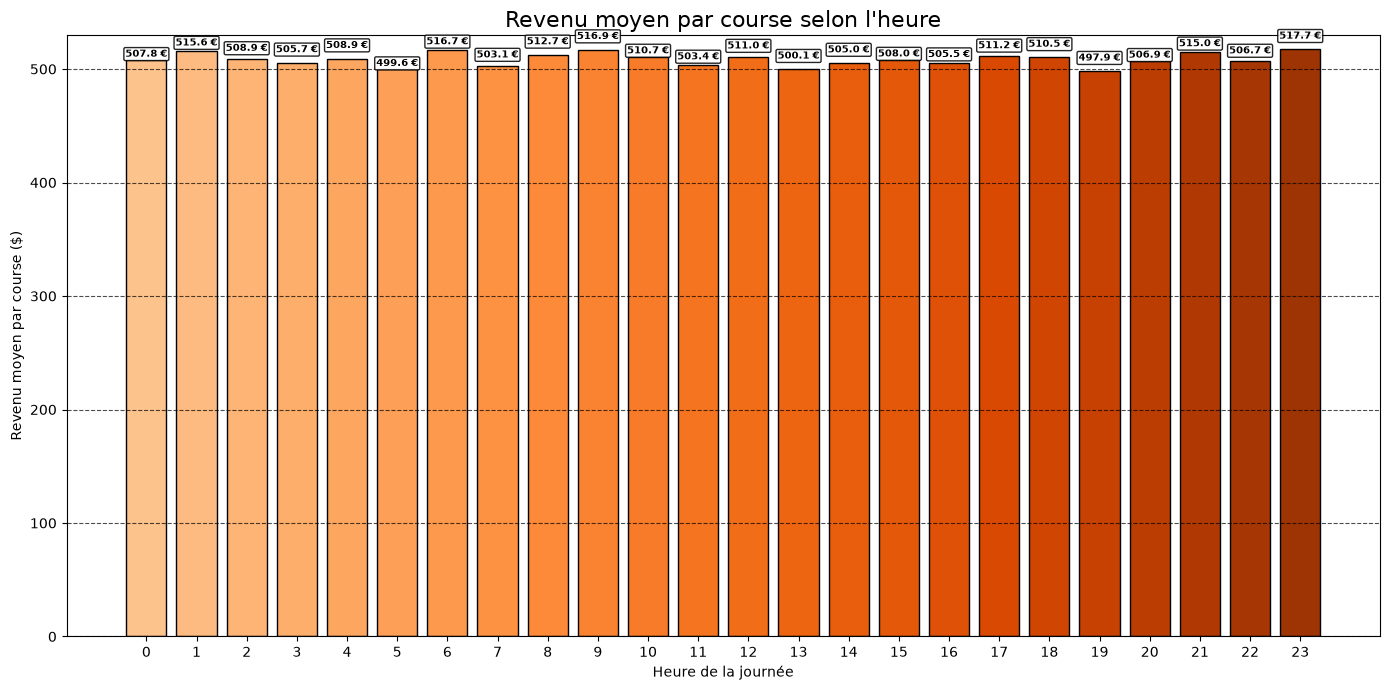

In [1523]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ==============================
# Revenu moyen selon l'heure
# ==============================

# Conversion de l'heure
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S",
    errors="coerce"
)


# Extraction de l'heure
df["Heure"] = df["Time"].dt.hour


# Revenu moyen par heure
revenu_heure = (
    df.groupby("Heure")["Booking Value"]
    .mean()
    .reindex(range(24))
)



# ==============================
# Création du graphique
# ==============================

fig, ax = plt.subplots(
    figsize=(14,7)
)


# Couleurs
couleurs = plt.cm.Oranges(
    np.linspace(0.3, 0.9, len(revenu_heure))
)


bars = ax.bar(
    revenu_heure.index,
    revenu_heure.values,
    color=couleurs,
    edgecolor="black"
)



# ==============================
# Valeurs avec bbox décalées
# ==============================

# Différents niveaux de hauteur
niveaux = [
    1,
    3,
    5,
    7,
    7.5,
    
]


for i, bar in enumerate(bars):

    valeur = bar.get_height()


    # alternance des hauteurs
    decalage = niveaux[i % 5]


    ax.text(
        bar.get_x() + bar.get_width()/2,
        valeur + decalage,
        f"{valeur:.1f} €",
        ha="center",
        va="bottom",
        fontsize=7.2,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )



# ==============================
# Mise en forme
# ==============================


# Marge pour les bbox
ax.set_ylim(
    0,
    revenu_heure.max() + 12
)


ax.set_title(
    "Revenu moyen par course selon l'heure",
    fontsize=16
)


ax.set_xlabel(
    "Heure de la journée"
)


ax.set_ylabel(
    "Revenu moyen par course ($)"
)



# Garder les heures verticales
ax.set_xticks(
    range(24)
)


ax.set_xticklabels(
    range(24)
)



# Grille
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.tight_layout()

plt.show()

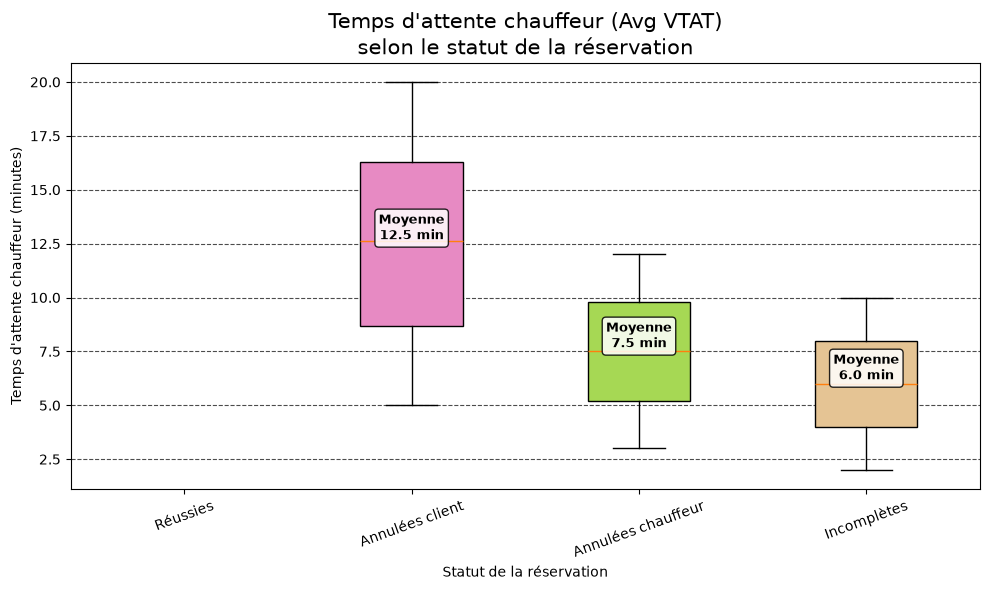

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ==============================
# Préparation des données
# ==============================

df_vtat = df[
    df["Avg VTAT"].notna()
].copy()


# Regroupement des statuts
df_vtat["Statut analyse"] = df_vtat["Booking Status"].replace(
    {
        "Completed": "Réussies",
        "Cancelled by Customer": "Annulées client",
        "Cancelled by Driver": "Annulées chauffeur",
        "Incomplete": "Incomplètes"
    }
)


# Statuts à afficher
ordre = [
    "Réussies",
    "Annulées client",
    "Annulées chauffeur",
    "Incomplètes"
]


donnees = [
    df_vtat.loc[
        df_vtat["Statut analyse"] == statut,
        "Avg VTAT"
    ]
    for statut in ordre
]


# Moyennes
moyennes = [
    valeurs.mean()
    for valeurs in donnees
]

# ==============================
# Taux des annulations
# ==============================

nb_annulations_client = (
    df_vtat["Statut analyse"] == "Annulées client"
).sum()

nb_annulations_chauffeur = (
    df_vtat["Statut analyse"] == "Annulées chauffeur"
).sum()

total_annulations = (
    nb_annulations_client +
    nb_annulations_chauffeur
)

taux_client = (
    nb_annulations_client /
    total_annulations * 100
)

taux_chauffeur = (
    nb_annulations_chauffeur /
    total_annulations * 100
)

# ==============================
# Création du graphique
# ==============================

fig, ax = plt.subplots(
    figsize=(10,6)
)


# Couleurs
couleurs = plt.cm.Set2(
    np.linspace(0.2,0.8,len(ordre))
)


box = ax.boxplot(
    donnees,
    tick_labels=ordre,
    patch_artist=True
)


# Application des couleurs
for patch, couleur in zip(box["boxes"], couleurs):
    patch.set_facecolor(couleur)



# ==============================
# Affichage des moyennes
# ==============================

for i, (statut, moyenne) in enumerate(zip(ordre, moyennes)):

    texte = f"Moyenne\n{moyenne:.1f} min"

    if statut == "Annulées client":
        texte += f"\n{taux_client:.1f} %\ndes annulations"

    elif statut == "Annulées chauffeur":
        texte += f"\n{taux_chauffeur:.1f} %\ndes annulations"

    ax.text(
        i + 1,
        moyenne,
        texte,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )



# ==============================
# Mise en forme
# ==============================

ax.set_title(
    "Temps d'attente chauffeur (Avg VTAT)\nselon le statut de la réservation",
    fontsize=15
)


ax.set_xlabel(
    "Statut de la réservation"
)


ax.set_ylabel(
    "Temps d'attente chauffeur (minutes)"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.xticks(
    rotation=20
)


plt.tight_layout()
plt.show()

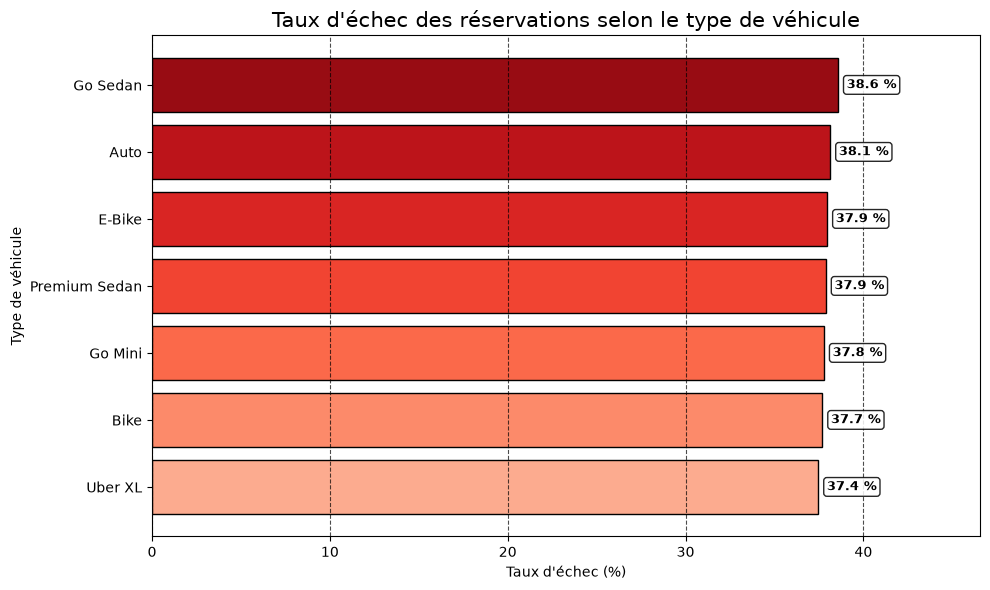

In [1528]:
import matplotlib.pyplot as plt
import numpy as np


# ==============================
# Taux d'échec par type de véhicule
# ==============================

taux_echec_vehicule = (
    df.groupby("Vehicle Type")["Booking Status"]
    .apply(
        lambda x: (
            x != "Success"
        ).mean() * 100
    )
    .sort_values()
)



# ==============================
# Graphique
# ==============================

fig, ax = plt.subplots(
    figsize=(10,6)
)


# Couleurs
couleurs = plt.cm.Reds(
    np.linspace(0.3,0.9,len(taux_echec_vehicule))
)


bars = ax.barh(
    taux_echec_vehicule.index,
    taux_echec_vehicule.values,
    color=couleurs,
    edgecolor="black"
)



# ==============================
# Affichage des valeurs
# ==============================

for i, bar in enumerate(bars):

    valeur = bar.get_width()

    ax.text(
        valeur + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{valeur:.1f} %",
        va="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )



# Marge pour les annotations
ax.set_xlim(
    0,
    taux_echec_vehicule.max() + 8
)



# ==============================
# Mise en forme
# ==============================

ax.set_title(
    "Taux d'échec des réservations selon le type de véhicule",
    fontsize=15
)

ax.set_xlabel(
    "Taux d'échec (%)"
)

ax.set_ylabel(
    "Type de véhicule"
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
    color="black"
)


plt.tight_layout()
plt.show()